# 1. Import Libraries, Configuration Setup, and Load the Dataset


## 1.1 Install \& Import Libraries

In [1]:
# !pip install peft==0.13.2 transformers==4.41.1

In [2]:
# !pip install wordcloud

In [3]:
# !pip install imblearn

In [4]:
# !pip install lightgbm

In [5]:
# ── Standard library ─────────────────────────────────────
import os
import re
import gc
import json
import time
import random
import warnings
from pathlib import Path
from itertools import product, combinations
from collections import Counter

# ── Stats ────────────────────────────────────────────────
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests

# ── Core DS stack ────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ── Scikit-learn ─────────────────────────────────────────
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_curve,
    auc,
    accuracy_score,
)
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.utils import resample, shuffle
from sklearn.utils.class_weight import compute_class_weight

# ── Other ML ─────────────────────────────────────────────
from lightgbm import LGBMClassifier
import joblib

# ── NLTK ─────────────────────────────────────────────────
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ── PyTorch ──────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import OneCycleLR
from torch.amp import autocast, GradScaler

# ── Transformers ─────────────────────────────────────────
from transformers import (
    AutoTokenizer,
    AlbertForSequenceClassification,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)

# ── Notebook setup ───────────────────────────────────────
# %matplotlib inline
warnings.filterwarnings("ignore")
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)

True

## 1.2 Seeds \& Device

In [6]:
SEED = 2025

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

USE_FP16 = DEVICE.type == "cuda"
TORCH_COMPILE_OK = hasattr(torch, "compile") and DEVICE.type == "cuda"

Device: cpu


## 1.3 Configuration

In [7]:
DRIVE_PROJECT_PATH = "/content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/04_leave_one_aspect_out/05_efficacy_cost_only"
RAW_DATA_FILE = "data/drugscom_plus_ai_labels.csv"
OUTPUT_DIR = "outputs_text_only"

TEXT_COLUMN = "review"
LABEL_COLUMN = "aspect_5class"
LABEL_COLUMN_ENCODED = "sentiment_Encoded"

# Explicit ordinal class order (NOT alphabetical)
CLASS_NAMES = ["VERY_NEGATIVE", "NEGATIVE", "NEUTRAL", "POSITIVE", "VERY_POSITIVE"]
NUM_CLASSES = len(CLASS_NAMES)

# Training settings
VOCAB_SIZE = 10000
MAX_TOKEN_LENGTH = 200
BATCH_SIZE = 128
N_ITERATIONS = 10
RANDOM_STATE = 42
SEQ_MAX_GRAD_NORM = 5.0
MAX_GRAD_NORM = 1.0

# ── Model file paths ────────────────────────────────────
OUTPUT_PATH = Path(DRIVE_PROJECT_PATH) / OUTPUT_DIR
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

MODEL_PATHS = {
    "lr":      {"model": OUTPUT_PATH / "best_lr_model.joblib",   "params": OUTPUT_PATH / "best_lr_params.json"},
    "rf":      {"model": OUTPUT_PATH / "best_rf_model.joblib",   "params": OUTPUT_PATH / "best_rf_params.json"},
    "lgbm":    {"model": OUTPUT_PATH / "best_lgbm_model.joblib", "params": OUTPUT_PATH / "best_lgbm_params.json"},
    "gru":     {"model": OUTPUT_PATH / "best_gru_model.pth",     "params": OUTPUT_PATH / "best_gru_params.json"},
    "cnn":     {"model": OUTPUT_PATH / "best_cnn_model.pth",     "params": OUTPUT_PATH / "best_cnn_params.json"},
    "albert":  {"model": OUTPUT_PATH / "best_albert_model.pth",  "params": None},
    "biobert": {"model": OUTPUT_PATH / "best_biobert_model.pth", "params": None},
}

RAW_DATA_PATH = os.path.join(DRIVE_PROJECT_PATH, RAW_DATA_FILE)

print("--- Configuration Loaded ---")
print(f"  Project : {DRIVE_PROJECT_PATH}")
print(f"  Source  : {RAW_DATA_PATH}")
print(f"  Output  : {OUTPUT_PATH}")
print(f"  Classes : {CLASS_NAMES}")
print(f"  FP16    : {USE_FP16}")


--- Configuration Loaded ---
  Project : /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/04_leave_one_aspect_out/05_efficacy_cost_only
  Source  : /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/04_leave_one_aspect_out/05_efficacy_cost_only/data/drugscom_plus_ai_labels.csv
  Output  : /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/04_leave_one_aspect_out/05_efficacy_cost_only/outputs_text_only
  Classes : ['VERY_NEGATIVE', 'NEGATIVE', 'NEUTRAL', 'POSITIVE', 'VERY_POSITIVE']
  FP16    : False


## 1.4 Load the data

In [8]:
import os
if os.path.ismount("/content/drive"):
    # Already mounted, skip
    pass
else:
    !fusermount -u /content/drive 2>/dev/null
    !rm -rf /content/drive/*
    from google.colab import drive
    drive.mount("/content/drive/", force_remount=True)

df_raw = pd.read_csv(RAW_DATA_PATH, index_col=0)
print(f"Loaded {df_raw.shape[0]} rows.")

df_raw.head()

Mounted at /content/drive/
Loaded 102061 rows.


,drugName,ingredient_norm,ingredient_set_key,n_ingredients,condition,condition_norm,review,text_norm,rating,date,...,ai_p_very_positive,ai_efficacy,ai_safety,ai_burden,ai_cost,ai_model,ai_seed,ai_temp,ai_ts_utc,ai_raw_json
uniqueID,,,,,,,,,,,,,,,,,,,,,
124923,Allopurinol,allopurinol,allopurinol,1,Gout,gout,"""\r\n300 mg and colcris to reduce anything the...",""" 300 mg and colcris to reduce anything the mi...",3,18-Feb-17,...,0.0,POSITIVE,NEGATIVE,NEGATIVE,NEUTRAL,gpt-4o-mini,7,0.0,2026-02-04T17:13:02.612186+00:00,"[\n {\n ""index"": 0,\n ""ai_rat..."
127676,Phentermine,phentermine,phentermine,1,Weight Loss,weight loss,"""\r\nA previous poster Ryan Smith said &quot;I...",""" a previous poster ryan smith said ""i've seen...",10,16-Apr-17,...,0.5,POSITIVE,NEUTRAL,POSITIVE,NEUTRAL,gpt-4o-mini,7,0.0,2026-02-04T17:13:02.612311+00:00,"[\n {\n ""index"": 0,\n ""ai_rat..."
81819,Liraglutide,liraglutide,liraglutide,1,Obesity,obesity,""" began with the minimum 0.6 mg dose of Saxend...",""" began with the minimum 0.6 mg dose of saxend...",10,18-Mar-17,...,0.1,POSITIVE,NEGATIVE,NEUTRAL,NEUTRAL,gpt-4o-mini,7,0.0,2026-02-04T17:13:02.612391+00:00,"[\n {\n ""index"": 0,\n ""ai_rat..."
170223,Quetiapine,quetiapine,quetiapine,1,Bipolar Disorde,bipolar disorde,""" Caused depression and negative, self defeati...",""" caused depression and negative, self defeati...",1,25-Aug-16,...,0.0,NEGATIVE,NEGATIVE,NEGATIVE,NEUTRAL,gpt-4o-mini,7,0.0,2026-02-04T17:13:02.612469+00:00,"[\n {\n ""index"": 0,\n ""ai_rat..."
48454,Ethinyl estradiol / levonorgestrel,ethinyl estradiol / levonorgestrel,ethinyl estradiol / levonorgestrel,2,Birth Control,birth control,""" Ever since I started taking this birth contr...",""" ever since i started taking this birth contr...",1,30-Oct-17,...,0.0,NEGATIVE,NEGATIVE,NEGATIVE,NEUTRAL,gpt-4o-mini,7,0.0,2026-02-04T17:13:02.612538+00:00,"[\n {\n ""index"": 0,\n ""ai_rat..."


In [9]:
# -- R1 minimal two-aspect ablation: efficacy + cost -------------------
ASPECT_COLS = ["ai_efficacy", "ai_safety", "ai_burden", "ai_cost"]
RETAINED_ASPECTS = ["ai_efficacy", "ai_cost"]
DROPPED_ASPECTS = [asp for asp in ASPECT_COLS if asp not in RETAINED_ASPECTS]

WEIGHT_SCHEME_NAME = "efficacy_cost_only_integer_2112_scaled"
WEIGHT_SCHEME_NOTE = (
    "Reviewer ablation: retain only efficacy and cost to test whether the "
    "two high-weight aspects explain the fused-label performance. The R0 "
    "2:1:1:2 relative weights are kept for retained aspects and rescaled to "
    "the same [-6, 6] score range."
)

# Use the submitted 2:1:1:2 integer weights as the base policy.
# Safety and burden contribute zero; retained weights are rescaled to keep
# the weighted score comparable with the R0 [-6, 6] threshold scale.
BASE_ASPECT_WEIGHTS_RAW = {
    "ai_efficacy": 2.0,
    "ai_safety": 1.0,
    "ai_burden": 1.0,
    "ai_cost": 2.0,
}
ASPECT_WEIGHTS_RAW = {
    asp: (weight if asp in RETAINED_ASPECTS else 0.0)
    for asp, weight in BASE_ASPECT_WEIGHTS_RAW.items()
}
POLARITY_MAP = {"POSITIVE": 1, "NEUTRAL": 0, "NEGATIVE": -1}
TARGET_SCORE_RANGE = 6.0
WEIGHT_SCALE = TARGET_SCORE_RANGE / sum(abs(v) for v in ASPECT_WEIGHTS_RAW.values() if v != 0)
ASPECT_WEIGHTS = {k: float(v) * WEIGHT_SCALE for k, v in ASPECT_WEIGHTS_RAW.items()}

print(f"=== R1 weight scheme: {WEIGHT_SCHEME_NAME} ===")
print(WEIGHT_SCHEME_NOTE)
print("Retained aspects:", RETAINED_ASPECTS)
print("Dropped aspects:", DROPPED_ASPECTS)
print("Raw retained weights:", ASPECT_WEIGHTS_RAW)
print("Scaled retained weights (sum abs = 6):", {k: round(v, 4) for k, v in ASPECT_WEIGHTS.items()})

# -- 1. Per-record counts (unweighted, retained aspects only) -----
for val in ["POSITIVE", "NEGATIVE", "NEUTRAL"]:
    df_raw[f"n_{val.lower()}"] = (
        df_raw[RETAINED_ASPECTS].apply(lambda row: (row == val).sum(), axis=1)
    )

# -- 2. Weighted score normalized to R0 score range [-6, +6] --
df_raw["aspect_wscore"] = sum(
    ASPECT_WEIGHTS[asp] * df_raw[asp].map(POLARITY_MAP).fillna(0).astype(float)
    for asp in RETAINED_ASPECTS
)

df_raw["aspect_weight_scheme"] = WEIGHT_SCHEME_NAME
df_raw["retained_aspects"] = ",".join(RETAINED_ASPECTS)
df_raw["dropped_aspect"] = ",".join(DROPPED_ASPECTS)

print("=== Weighted aspect score distribution ===")
print(df_raw["aspect_wscore"].round(4).value_counts().sort_index())

print("=== Cross-tab: retained aspect counts ===")
print(f"Mean #POSITIVE per record: {df_raw['n_positive'].mean():.2f}")
print(f"Mean #NEGATIVE per record: {df_raw['n_negative'].mean():.2f}")
print(f"Mean #NEUTRAL  per record: {df_raw['n_neutral'].mean():.2f}")

# -- 3. Derive hard 5-class label from weighted score -----
# Keep the submitted R0 thresholds. Rescaling above keeps the score range comparable.
def wscore_to_5class(score):
    if score >= 5:
        return "VERY_POSITIVE"
    elif score >= 2:
        return "POSITIVE"
    elif score >= -1:
        return "NEUTRAL"
    elif score >= -4:
        return "NEGATIVE"
    else:
        return "VERY_NEGATIVE"

df_raw["aspect_5class"] = df_raw["aspect_wscore"].apply(wscore_to_5class)

print("=== Aspect-derived 5-class distribution ===")
print(df_raw["aspect_5class"].value_counts())


=== R1 weight scheme: efficacy_cost_only_integer_2112_scaled ===
Reviewer ablation: retain only efficacy and cost to test whether the two high-weight aspects explain the fused-label performance. The R0 2:1:1:2 relative weights are kept for retained aspects and rescaled to the same [-6, 6] score range.
Retained aspects: ['ai_efficacy', 'ai_cost']
Dropped aspects: ['ai_safety', 'ai_burden']
Raw retained weights: {'ai_efficacy': 2.0, 'ai_safety': 0.0, 'ai_burden': 0.0, 'ai_cost': 2.0}
Scaled retained weights (sum abs = 6): {'ai_efficacy': 3.0, 'ai_safety': 0.0, 'ai_burden': 0.0, 'ai_cost': 3.0}
=== Weighted aspect score distribution ===
aspect_wscore
-6.0     2001
-3.0    26435
 0.0    11107
 3.0    59507
 6.0     3011
Name: count, dtype: int64
=== Cross-tab: retained aspect counts ===
Mean #POSITIVE per record: 0.68
Mean #NEGATIVE per record: 0.34
Mean #NEUTRAL  per record: 0.98
=== Aspect-derived 5-class distribution ===
aspect_5class
POSITIVE         59507
NEGATIVE         26435
NEUTRA

# 2. Data Exploration \& Master Data Preparation

## 2.1 Data Preparation

In [ ]:
# Shuffle
df_raw = shuffle(df_raw, random_state=SEED).reset_index(drop=True)
df_raw

,drugName,ingredient_norm,ingredient_set_key,n_ingredients,condition,condition_norm,review,text_norm,rating,date,...,ai_ts_utc,ai_raw_json,n_positive,n_negative,n_neutral,aspect_wscore,aspect_weight_scheme,retained_aspects,dropped_aspect,aspect_5class
0,Benzoyl peroxide / clindamycin,benzoyl peroxide / clindamycin,benzoyl peroxide / clindamycin,2,Acne,acne,"""I was never one to have severe acne, just a f...","""i was never one to have severe acne, just a f...",10,20-May-15,...,2026-02-06T20:20:28.994460+00:00,"[\n {\n ""index"": 0,\n ""ai_rat...",1,0,1,3.0,efficacy_cost_only_integer_2112_scaled,"ai_efficacy,ai_cost","ai_safety,ai_burden",POSITIVE
1,Nexplanon,etonogestrel,etonogestrel,1,Birth Control,birth control,"""I&#039;ve had the Nexplanon since May 2015.I ...","""i've had the nexplanon since may 2015.i got i...",6,12-Oct-16,...,2026-02-07T05:19:51.777772+00:00,"[\n {\n ""index"": 0,\n ""ai_rat...",1,0,1,3.0,efficacy_cost_only_integer_2112_scaled,"ai_efficacy,ai_cost","ai_safety,ai_burden",POSITIVE
2,Buspirone,buspirone,buspirone,1,Anxiety,anxiety,"""I have been taking Buspar for just over 8 mon...","""i have been taking buspar for just over 8 mon...",10,1-Sep-08,...,2026-02-06T03:21:15.331673+00:00,"[\n {\n ""index"": 0,\n ""ai_rat...",1,0,1,3.0,efficacy_cost_only_integer_2112_scaled,"ai_efficacy,ai_cost","ai_safety,ai_burden",POSITIVE
3,Buspirone,buspirone,buspirone,1,Anxiety,anxiety,"""I&#039;ve been on this for two weeks. I went ...","""i've been on this for two weeks. i went to my...",8,22-Aug-16,...,2026-02-07T03:59:05.030105+00:00,"[\n {\n ""index"": 0,\n ""ai_rat...",1,0,1,3.0,efficacy_cost_only_integer_2112_scaled,"ai_efficacy,ai_cost","ai_safety,ai_burden",POSITIVE
4,Liraglutide,liraglutide,liraglutide,1,"Diabetes, Type 2","diabetes, type 2","""I Love this medication!!! My blood sugar stay...","""i love this medication!!! my blood sugar stay...",9,27-Oct-15,...,2026-02-06T10:31:30.435742+00:00,"[\n {\n ""index"": 0,\n ""ai_rat...",1,1,0,0.0,efficacy_cost_only_integer_2112_scaled,"ai_efficacy,ai_cost","ai_safety,ai_burden",NEUTRAL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102056,Plan B One-Step,levonorgestrel,levonorgestrel,1,Emergency Contraception,emergency contraception,"""My lover and I had unprotected sex on 12/26 w...","""my lover and i had unprotected sex on 12/26 w...",9,11-Jan-16,...,2026-02-07T20:01:52.784926+00:00,"[\n {\n ""index"": 0,\n ""ai_rat...",1,0,1,3.0,efficacy_cost_only_integer_2112_scaled,"ai_efficacy,ai_cost","ai_safety,ai_burden",POSITIVE
102057,Esomeprazole / naproxen,esomeprazole / naproxen,esomeprazole / naproxen,2,Osteoarthritis,osteoarthritis,"""Great for relief of back pain BUT severe side...","""great for relief of back pain but severe side...",3,24-Aug-16,...,2026-02-05T01:12:26.595098+00:00,"[\n {\n ""index"": 0,\n ""ai_rat...",0,1,1,-3.0,efficacy_cost_only_integer_2112_scaled,"ai_efficacy,ai_cost","ai_safety,ai_burden",NEGATIVE
102058,Dupilumab,dupilumab,dupilumab,1,Eczema,eczema,"""I am a 30 year old female who has had eczema ...","""i am a 30 year old female who has had eczema ...",8,28-Aug-17,...,2026-02-05T05:06:26.707305+00:00,"[\n {\n ""index"": 0,\n ""ai_rat...",1,0,1,3.0,efficacy_cost_only_integer_2112_scaled,"ai_efficacy,ai_cost","ai_safety,ai_burden",POSITIVE
102059,Letrozole,letrozole,letrozole,1,Breast Cance,breast cance,"""Used for 4.6years. Experienced many common s...","""used for 4.6years. experienced many common si...",10,11-Jun-16,...,2026-02-08T01:40:10.647322+00:00,"[\n {\n ""index"": 0,\n ""ai_rat...",0,0,2,0.0,efficacy_cost_only_integer_2112_scaled,"ai_efficacy,ai_cost","ai_safety,ai_burden",NEUTRAL


## 2.2 Master Data Preparation

In [ ]:
def clean_text(text: str) -> str:
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+", " urltoken ", text)
    text = re.sub(r"@\w+", " usertoken ", text)
    text = re.sub(r"#(\w+)", r" hashtag_\1 ", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


print("Cleaning text...")
df_clean = df_raw.copy()
df_clean[TEXT_COLUMN] = df_clean[TEXT_COLUMN].apply(clean_text)

Cleaning text...


In [ ]:
label_encoder = LabelEncoder()
label_encoder.classes_ = np.array(CLASS_NAMES)  # force ordinal order
df_clean[LABEL_COLUMN_ENCODED] = label_encoder.transform(df_clean[LABEL_COLUMN])

print(f"Label mapping: {dict(zip(CLASS_NAMES, range(NUM_CLASSES)))}")
print(f"df_clean: {df_clean.shape[0]} rows")


Label mapping: {'VERY_NEGATIVE': 0, 'NEGATIVE': 1, 'NEUTRAL': 2, 'POSITIVE': 3, 'VERY_POSITIVE': 4}
df_clean: 102061 rows


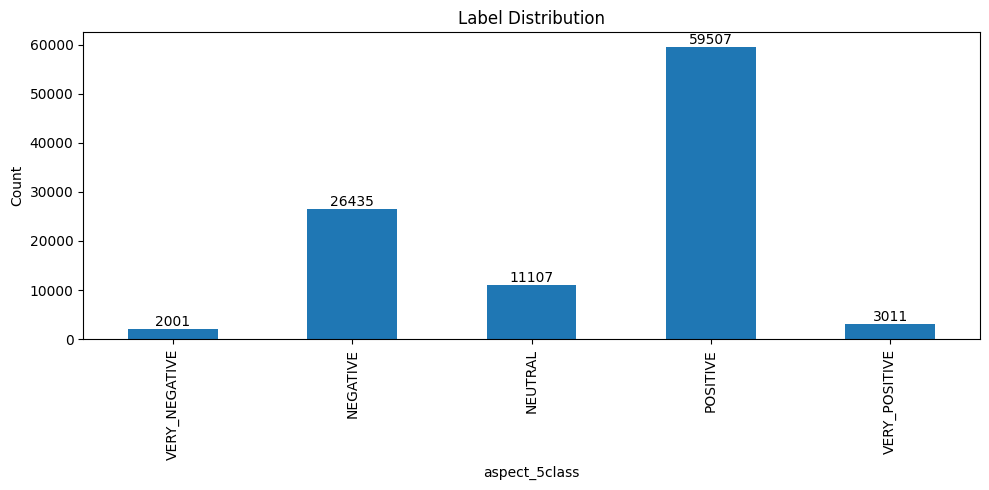

In [ ]:
plt.figure(figsize=(10, 5))
counts = df_clean[LABEL_COLUMN].value_counts().reindex(CLASS_NAMES)
ax = counts.plot(kind="bar")
for i, v in enumerate(counts):
    ax.text(i, v, str(v), ha="center", va="bottom")
plt.title("Label Distribution")
plt.xlabel(LABEL_COLUMN)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 2.3 Master Data Split

In [ ]:
groups = df_clean[TEXT_COLUMN]
y = df_clean[LABEL_COLUMN_ENCODED]

# 80/20 → trainval / test
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
trainval_idx, test_idx = next(gss_test.split(df_clean, y, groups=groups))

split = np.full(len(df_clean), "train", dtype=object)
split[test_idx] = "test"

# 75/25 of trainval → train / val (≈60/20/20)
df_trainval = df_clean.iloc[trainval_idx].copy().reset_index(drop=True)
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx2, val_idx = next(
    gss_val.split(df_trainval, df_trainval[LABEL_COLUMN_ENCODED], groups=df_trainval[TEXT_COLUMN])
)
split[trainval_idx[val_idx]] = "val"
df_clean["split"] = split

print("Split counts:")
print(df_clean["split"].value_counts())

# Leakage check
n_leaky = (df_clean.groupby(TEXT_COLUMN)["split"].nunique() > 1).sum()
assert n_leaky == 0, f"{n_leaky} text groups leak across splits!"
print(f"Leakage check passed.")

print("Split proportions:")
print(df_clean["split"].value_counts(normalize=True))

# Save master split
split_path = OUTPUT_PATH / "DrugReview_master_split.csv"
df_clean.to_csv(split_path, index=False)
print(f"Saved → {split_path}")

Split counts:
split
train    61309
test     20383
val      20369
Name: count, dtype: int64
Leakage check passed.
Split proportions:
split
train    0.600709
test     0.199714
val      0.199577
Name: proportion, dtype: float64
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/04_leave_one_aspect_out/05_efficacy_cost_only/outputs_text_only/DrugReview_master_split.csv


## 2.4 Shared helper functions

### 2.4.1 Bootstrap CI

In [ ]:
def bootstrap_f1_ci(y_true, y_pred, n_iterations=1000, average="weighted"):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    scores = []
    for _ in range(n_iterations):
        idx = resample(np.arange(len(y_true)))
        try:
            scores.append(f1_score(y_true[idx], y_pred[idx], average=average))
        except ValueError:
            continue
    if not scores:
        return np.nan, np.nan, np.nan
    return np.mean(scores), np.percentile(scores, 2.5), np.percentile(scores, 97.5)


def bootstrap_auc_ci(y_true, y_scores, n_iterations=1000, average="macro"):
    y_true, y_scores = np.asarray(y_true), np.asarray(y_scores)
    scores = []
    for _ in range(n_iterations):
        idx = resample(np.arange(len(y_true)))
        try:
            scores.append(
                roc_auc_score(y_true[idx], y_scores[idx], average=average, multi_class="ovr")
            )
        except ValueError:
            continue
    if not scores:
        return np.nan, np.nan, np.nan
    return np.mean(scores), np.percentile(scores, 2.5), np.percentile(scores, 97.5)

### 2.4.2 Plotting

In [ ]:
def plot_confusion_matrix(y_true, y_pred, labels, title="Model", save_dir=None):
    """Works for both string labels (ML) and int labels (DL)."""
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix — {title}")
    plt.tight_layout()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        path = os.path.join(save_dir, f"{title}_confusion_matrix.png")
        plt.savefig(path, dpi=300)
        print(f"Saved → {path}")
    plt.show()


def plot_multiclass_roc(y_true, y_score, classes_list, title="Model", save_dir=None):
    """Works for both string and int class lists."""
    y_true_bin = label_binarize(y_true, classes=classes_list)
    n_classes = len(classes_list)
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    colors = sns.color_palette("mako", n_classes)
    plt.figure(figsize=(10, 8))
    for i, (cls, color) in enumerate(zip(classes_list, colors)):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f"{cls} (AUC={roc_auc[i]:.2f})")
    plt.plot([0, 1], [0, 1], "k--", lw=2)
    plt.xlim([0, 1])
    plt.ylim([0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{title} — Multi-class ROC")
    plt.legend(loc="lower right")
    plt.tight_layout()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        path = os.path.join(save_dir, f"{title}_roc_curve.png")
        plt.savefig(path, dpi=300)
        print(f"Saved → {path}")
    plt.show()

### 2.4.3 Machine Learning Evaluation Wrapper

In [ ]:
def evaluate_ml(model, X_test, y_test, model_name="Model"):
    """Full evaluation for a fitted sklearn classifier."""
    print(f"\n{'='*50}")
    print(f"Evaluation: {model_name}")
    print(f"{'='*50}")

    y_pred = model.predict(X_test)
    classes = model.classes_

    print(classification_report(y_test, y_pred, digits=4, labels=classes))

    f1_m, f1_lo, f1_hi = bootstrap_f1_ci(y_test, y_pred)
    print(f"Weighted F1: {f1_m:.4f}  95% CI [{f1_lo:.4f}, {f1_hi:.4f}]")

    plot_confusion_matrix(y_test, y_pred, labels=classes,
                         title=model_name, save_dir=str(OUTPUT_PATH))

    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test)
    elif hasattr(model, "decision_function"):
        y_scores = model.decision_function(X_test)
    else:
        print("No probability scores available.")
        return

    auc_m, auc_lo, auc_hi = bootstrap_auc_ci(y_test, y_scores)
    print(f"Macro AUC: {auc_m:.4f}  95% CI [{auc_lo:.4f}, {auc_hi:.4f}]")

    plot_multiclass_roc(y_test, y_scores, classes,
                       title=model_name, save_dir=str(OUTPUT_PATH))

### 2.4.4 PyTorch Evaluation Wrapper

In [ ]:
@torch.no_grad()
def evaluate_pytorch(model, test_loader, label_encoder, model_name="Model",
                     use_attention_mask=True):
    """Full evaluation for a PyTorch classifier."""
    model.eval().to(DEVICE)
    all_preds, all_probs, all_labels = [], [], []

    for batch in tqdm(test_loader, desc=f"Eval {model_name}"):
        ids = batch["input_ids"].to(DEVICE, non_blocking=True)
        labels = batch["label"].to(DEVICE, non_blocking=True)

        if use_attention_mask:
            mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
            with autocast("cuda", enabled=USE_FP16):
                outputs = model(input_ids=ids, attention_mask=mask)
        else:
            with autocast("cuda", enabled=USE_FP16):
                outputs = model(input_ids=ids)

        logits = outputs.logits if hasattr(outputs, "logits") else outputs
        probs = torch.softmax(logits.float(), dim=1)
        preds = probs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    classes_str = label_encoder.classes_
    classes_int = np.arange(NUM_CLASSES)

    print(f"\n{'='*50}")
    print(f"Evaluation: {model_name}")
    print(f"{'='*50}")

    print(classification_report(all_labels, all_preds,
                                target_names=classes_str, digits=4))

    f1_m, f1_lo, f1_hi = bootstrap_f1_ci(all_labels, all_preds)
    print(f"Weighted F1: {f1_m:.4f}  95% CI [{f1_lo:.4f}, {f1_hi:.4f}]")

    plot_confusion_matrix(all_labels, all_preds, labels=classes_int,
                         title=model_name, save_dir=str(OUTPUT_PATH))

    auc_m, auc_lo, auc_hi = bootstrap_auc_ci(all_labels, all_probs)
    print(f"Macro AUC: {auc_m:.4f}  95% CI [{auc_lo:.4f}, {auc_hi:.4f}]")

    plot_multiclass_roc(all_labels, all_probs, classes_int,
                       title=model_name, save_dir=str(OUTPUT_PATH))

    return all_preds, all_probs, all_labels

### 2.4.5 Machine Learning Feature Importance (shared)

In [ ]:

def plot_feature_importance(importances, feature_names, model_name="Model", top_n=20):
    """Generic feature importance plot for any ML model."""
    df_imp = pd.DataFrame({"Feature": feature_names, "Importance": importances})
    df_imp["Scaled"] = (df_imp["Importance"] / df_imp["Importance"].max()) * 100
    top = df_imp.sort_values("Importance", ascending=False).head(top_n)

    plt.figure(figsize=(8, 6))
    sns.set_style("whitegrid")
    sns.barplot(x="Scaled", y="Feature", data=top[::-1], palette="mako")
    plt.title(f"Top {top_n} Feature Importance ({model_name})", fontsize=14, fontweight="bold")
    plt.xlabel("Relative Importance (%)")
    plt.ylabel("Feature")
    plt.tight_layout()

    path = OUTPUT_PATH / f"{model_name.lower().replace(' ', '_')}_feature_importance.png"
    plt.savefig(path, dpi=300)
    print(f"Saved → {path}")
    plt.show()

    return top

# 3. Classical ML Modeling

## 3.0 Pre-processing for classical ML Models


In [ ]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def ml_preprocess(text: str) -> str:
    if not isinstance(text, str):
        return ""
    tokens = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words]
    return " ".join(tokens)


df_ml = df_clean.copy()
df_ml["text_ml"] = df_ml[TEXT_COLUMN].apply(ml_preprocess)

df_train_ml = df_ml[df_ml["split"] == "train"].copy()
df_val_ml   = df_ml[df_ml["split"] == "val"].copy()
df_test_ml  = df_ml[df_ml["split"] == "test"].copy()

X_train_ml = df_train_ml["text_ml"].tolist()
X_val_ml   = df_val_ml["text_ml"].tolist()
X_test_ml  = df_test_ml["text_ml"].tolist()

y_train_ml = df_train_ml[LABEL_COLUMN].astype(str).values
y_val_ml   = df_val_ml[LABEL_COLUMN].astype(str).values
y_test_ml  = df_test_ml[LABEL_COLUMN].astype(str).values

# TF-IDF (no stop_words param — already removed in ml_preprocess)
tfidf = TfidfVectorizer(max_features=VOCAB_SIZE)
X_train_tfidf = tfidf.fit_transform(X_train_ml)
X_val_tfidf   = tfidf.transform(X_val_ml)
X_test_tfidf  = tfidf.transform(X_test_ml)

print(f"TF-IDF: train={X_train_tfidf.shape}, val={X_val_tfidf.shape}, test={X_test_tfidf.shape}")
feature_names_tfidf = tfidf.get_feature_names_out()

print(f"ML splits: train={len(df_train_ml)}, val={len(df_val_ml)}, test={len(df_test_ml)}")

TF-IDF: train=(61309, 10000), val=(20369, 10000), test=(20383, 10000)
ML splits: train=61309, val=20369, test=20383


## 3.1 Logistic Regression

### Step 1: Hyperparameter Tuning

In [ ]:
RETRAIN = True
if RETRAIN:
    # 7.1 Hyperparameter Tuning (grid search)
    set_seed()
    print("Tuning Logistic Regression...")
    start = time.time()

    lr_grid = {
        "C": [0.1, 1, 10],
        "solver": ["lbfgs", "saga"],
        "class_weight": ["balanced", None],
    }

    best_f1_lr, best_model_lr, best_params_lr = 0, None, None

    for C, solver, cw in product(lr_grid["C"], lr_grid["solver"], lr_grid["class_weight"]):
        try:
            model = LogisticRegression(
                C=C, solver=solver, penalty="l2", multi_class="multinomial",
                class_weight=cw, max_iter=1000, random_state=RANDOM_STATE,
                n_jobs=-1 if solver == "saga" else None,
            )
            model.fit(X_train_tfidf, y_train_ml)
            f1 = f1_score(y_val_ml, model.predict(X_val_tfidf), average="weighted")
            if f1 > best_f1_lr:
                best_f1_lr = f1
                best_model_lr = model
                best_params_lr = {"C": C, "solver": solver, "class_weight": cw}
                print(f"  LR F1={f1:.4f} | {best_params_lr}")
        except Exception as e:
            print(f"  Skipped: {e}")

    print(f"LR tuning: {time.time()-start:.1f}s | Best F1={best_f1_lr:.4f}")

    joblib.dump(best_model_lr, MODEL_PATHS["lr"]["model"])
    with open(MODEL_PATHS["lr"]["params"], "w") as f:
        json.dump(best_params_lr, f, indent=2)
else:
    print("Loading LR from disk...")
    best_model_lr = joblib.load(MODEL_PATHS["lr"]["model"])
    print(f"Loaded LR from {MODEL_PATHS['lr']['model']}")

Tuning Logistic Regression...
  LR F1=0.5969 | {'C': 0.1, 'solver': 'lbfgs', 'class_weight': 'balanced'}
  LR F1=0.6398 | {'C': 0.1, 'solver': 'lbfgs', 'class_weight': None}
  LR F1=0.6399 | {'C': 0.1, 'solver': 'saga', 'class_weight': None}
  LR F1=0.6880 | {'C': 1, 'solver': 'lbfgs', 'class_weight': None}
LR tuning: 634.2s | Best F1=0.6880


### Step 2: Model Evaluation


Evaluation: Logistic_Regression
               precision    recall  f1-score   support

     NEGATIVE     0.6839    0.6367    0.6594      5246
      NEUTRAL     0.4789    0.1629    0.2431      2229
     POSITIVE     0.7470    0.9140    0.8221     11933
VERY_NEGATIVE     0.6087    0.0698    0.1253       401
VERY_POSITIVE     0.5054    0.0819    0.1409       574

     accuracy                         0.7205     20383
    macro avg     0.6048    0.3731    0.3982     20383
 weighted avg     0.6919    0.7205    0.6840     20383

Weighted F1: 0.6839  95% CI [0.6770, 0.6912]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/04_leave_one_aspect_out/05_efficacy_cost_only/outputs_text_only/Logistic_Regression_confusion_matrix.png


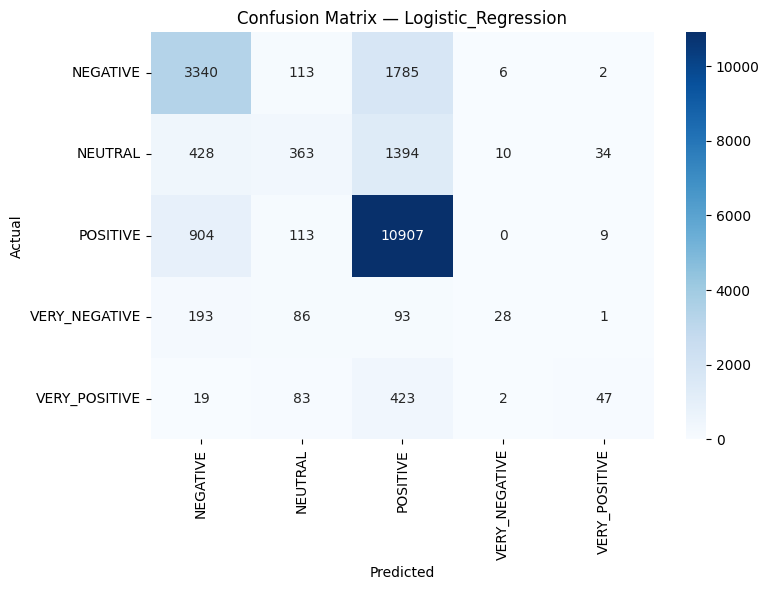

Macro AUC: 0.8377  95% CI [0.8319, 0.8437]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/04_leave_one_aspect_out/05_efficacy_cost_only/outputs_text_only/Logistic_Regression_roc_curve.png


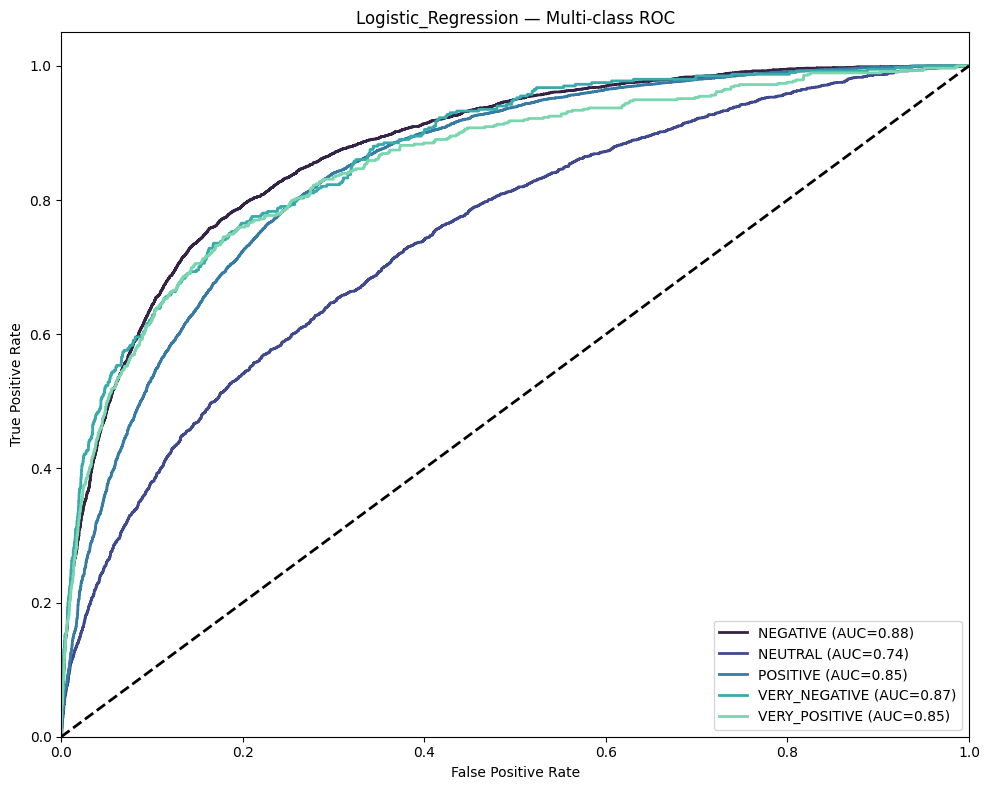

In [ ]:
evaluate_ml(best_model_lr, X_test_tfidf, y_test_ml, "Logistic_Regression")

### Step 3: Model Interpretation

Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/04_leave_one_aspect_out/05_efficacy_cost_only/outputs_text_only/logistic_regression_feature_importance.png


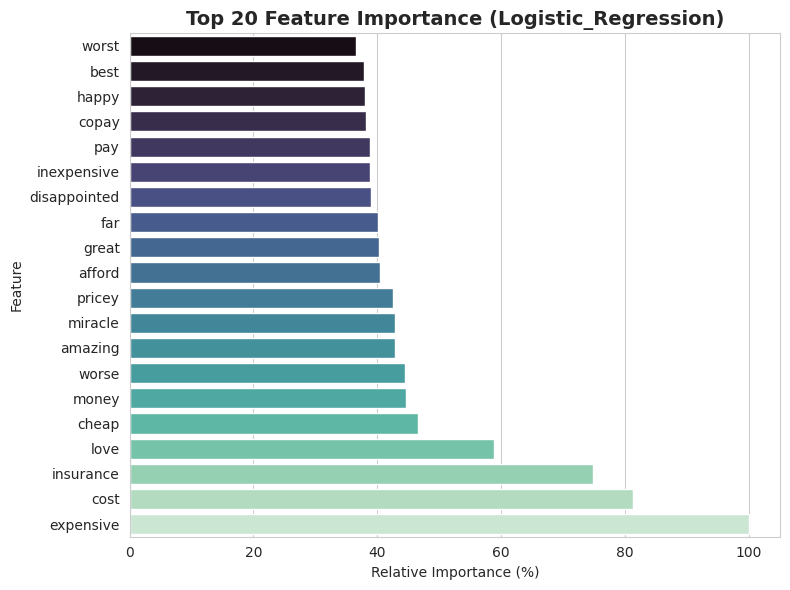

In [ ]:
if hasattr(best_model_lr, "coef_"):
    importances_lr = np.abs(best_model_lr.coef_).mean(axis=0) if best_model_lr.coef_.shape[0] > 1 else np.abs(best_model_lr.coef_[0])
    plot_feature_importance(importances_lr, feature_names_tfidf, "Logistic_Regression")

## 3.2 Random Forest

### Step 1: Hyperparameter Tuning

In [ ]:
RETRAIN = True
if RETRAIN:
    set_seed()
    print("\nTuning Random Forest...")
    start = time.time()

    rf_grid = {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "class_weight": ["balanced", None],
    }

    best_f1_rf, best_model_rf, best_params_rf = 0, None, None

    for n_est, md, mss, msl, cw in tqdm(
        list(product(rf_grid["n_estimators"], rf_grid["max_depth"],
                     rf_grid["min_samples_split"], rf_grid["min_samples_leaf"],
                     rf_grid["class_weight"])),
        desc="RF grid"
    ):
        try:
            model = RandomForestClassifier(
                n_estimators=n_est, max_depth=md, min_samples_split=mss,
                min_samples_leaf=msl, class_weight=cw,
                random_state=RANDOM_STATE, n_jobs=-1,
            )
            model.fit(X_train_tfidf, y_train_ml)
            f1 = f1_score(y_val_ml, model.predict(X_val_tfidf), average="weighted")
            if f1 > best_f1_rf:
                best_f1_rf = f1
                best_model_rf = model
                best_params_rf = {"n_estimators": n_est, "max_depth": md,
                                  "min_samples_split": mss, "min_samples_leaf": msl,
                                  "class_weight": cw}
        except Exception as e:
            print(f"  Skipped: {e}")

    print(f"RF tuning: {time.time()-start:.1f}s | Best F1={best_f1_rf:.4f}")
    print(f"Best params: {best_params_rf}")

    joblib.dump(best_model_rf, MODEL_PATHS["rf"]["model"])
    with open(MODEL_PATHS["rf"]["params"], "w") as f:
        json.dump(best_params_rf, f, indent=2)
else:
    print("Loading RF from disk...")
    best_model_rf = joblib.load(MODEL_PATHS["rf"]["model"])
    print(f"Loaded RF from {MODEL_PATHS['rf']['model']}")


Tuning Random Forest...


RF grid: 100%|██████████| 162/162 [35:45<00:00, 13.24s/it]


RF tuning: 2145.4s | Best F1=0.6633
Best params: {'n_estimators': 200, 'max_depth': None, 'min_samples_split': 10, 'min_samples_leaf': 4, 'class_weight': 'balanced'}


### Step 2: Model Evaluation


Evaluation: RandomForest
               precision    recall  f1-score   support

     NEGATIVE     0.5803    0.6519    0.6141      5246
      NEUTRAL     0.4489    0.1516    0.2267      2229
     POSITIVE     0.7564    0.8320    0.7924     11933
VERY_NEGATIVE     0.3478    0.2195    0.2691       401
VERY_POSITIVE     0.4039    0.2526    0.3108       574

     accuracy                         0.6829     20383
    macro avg     0.5075    0.4215    0.4426     20383
 weighted avg     0.6595    0.6829    0.6608     20383

Weighted F1: 0.6608  95% CI [0.6540, 0.6679]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/04_leave_one_aspect_out/05_efficacy_cost_only/outputs_text_only/RandomForest_confusion_matrix.png


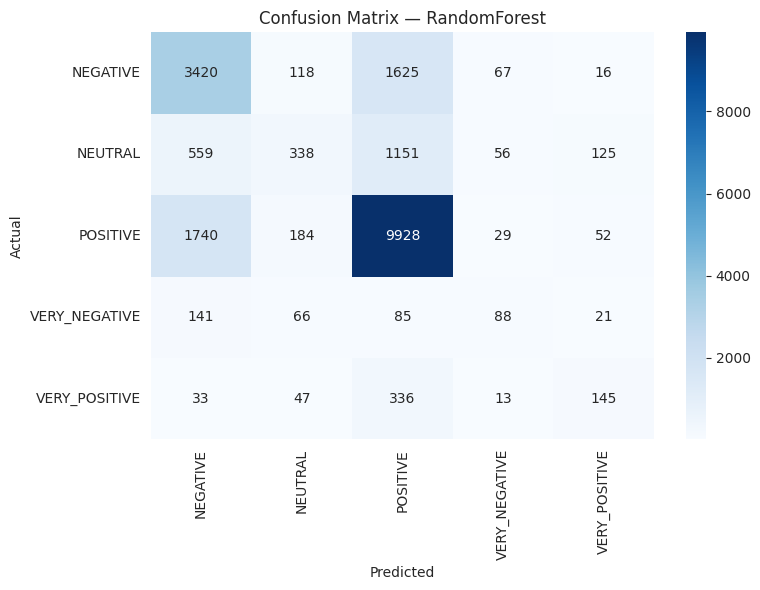

Macro AUC: 0.8000  95% CI [0.7933, 0.8067]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/04_leave_one_aspect_out/05_efficacy_cost_only/outputs_text_only/RandomForest_roc_curve.png


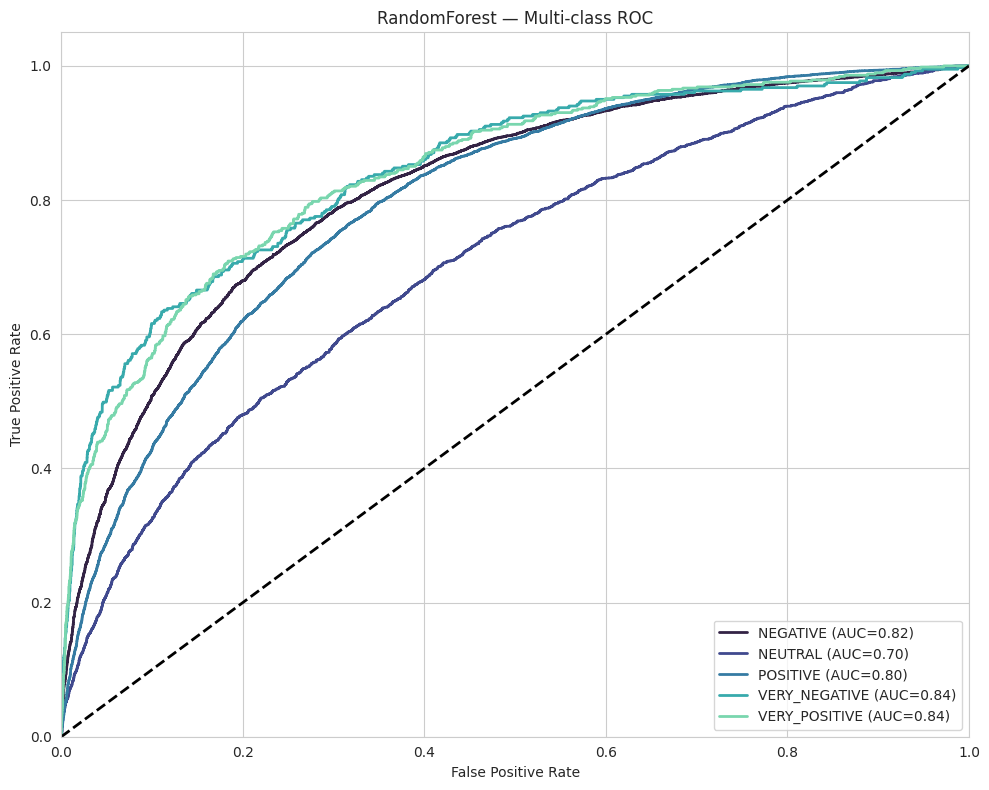

In [ ]:
evaluate_ml(best_model_rf, X_test_tfidf, y_test_ml, "RandomForest")

### Step 3: Model Interpretation

Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/04_leave_one_aspect_out/05_efficacy_cost_only/outputs_text_only/randomforest_feature_importance.png


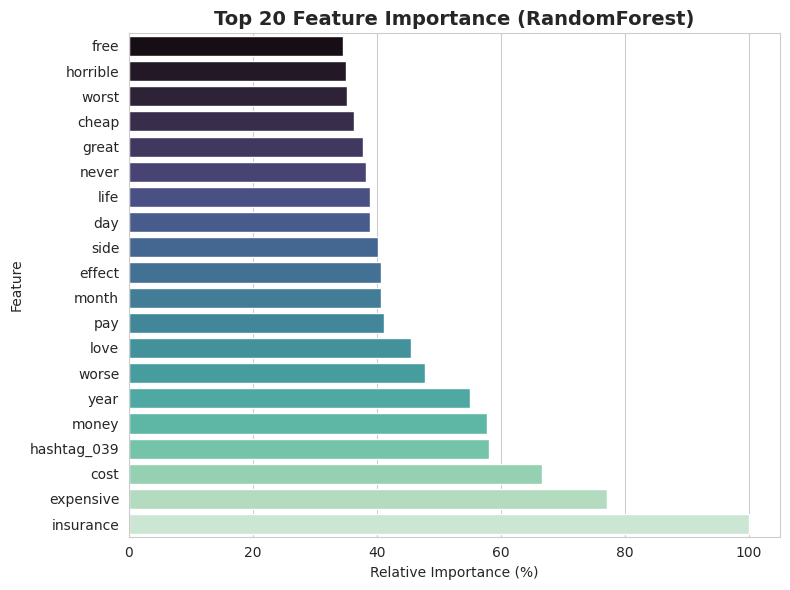

,Feature,Importance,Scaled
4908,insurance,0.012693,100.000000
3626,expensive,0.009795,77.172668
2526,cost,0.008449,66.566620
4383,hashtag_039,0.007364,58.015914
5865,money,0.007327,57.725580
9920,year,0.006992,55.086422
9855,worse,0.006070,47.819852
5466,love,0.005764,45.414381
6539,pay,0.005227,41.177809
5880,month,0.005170,40.733322


In [ ]:
plot_feature_importance(best_model_rf.feature_importances_, feature_names_tfidf, "RandomForest")

## 3.2 LGBM

### Step 1: Hyperparameter Tuning

In [ ]:
RETRAIN = True
if RETRAIN:
    set_seed()
    print("\nTuning LightGBM...")
    start = time.time()

    lgbm_grid = {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.1, 0.2],
        "num_leaves": [31, 63],
        "max_depth": [None, 10],
        "class_weight": ["balanced", None],
    }

    best_f1_lgbm, best_model_lgbm, best_params_lgbm = 0, None, None

    for n_est, lr, nl, md, cw in tqdm(
        list(product(lgbm_grid["n_estimators"], lgbm_grid["learning_rate"],
                     lgbm_grid["num_leaves"], lgbm_grid["max_depth"],
                     lgbm_grid["class_weight"])),
        desc="LGBM grid"
    ):
        try:
            model = LGBMClassifier(
                objective="multiclass", n_estimators=n_est, learning_rate=lr,
                num_leaves=nl, max_depth=-1 if md is None else md,
                class_weight=cw, random_state=RANDOM_STATE, n_jobs=-1,
                verbose=-1,
            )
            model.fit(X_train_tfidf, y_train_ml)
            f1 = f1_score(y_val_ml, model.predict(X_val_tfidf), average="weighted")
            if f1 > best_f1_lgbm:
                best_f1_lgbm = f1
                best_model_lgbm = model
                best_params_lgbm = {"n_estimators": n_est, "learning_rate": lr,
                                    "num_leaves": nl, "max_depth": md, "class_weight": cw}
        except Exception as e:
            print(f"  Skipped: {e}")

    print(f"LGBM tuning: {time.time()-start:.1f}s | Best F1={best_f1_lgbm:.4f}")
    print(f"Best params: {best_params_lgbm}")

    joblib.dump(best_model_lgbm, MODEL_PATHS["lgbm"]["model"])
    with open(MODEL_PATHS["lgbm"]["params"], "w") as f:
        json.dump(best_params_lgbm, f, indent=2)
else:
    print("Loading LGBM from disk...")
    best_model_lgbm = joblib.load(MODEL_PATHS["lgbm"]["model"])
    print(f"Loaded LGBM from {MODEL_PATHS['lgbm']['model']}")



Tuning LightGBM...


LGBM grid: 100%|██████████| 48/48 [1:27:24<00:00, 109.27s/it]

LGBM tuning: 5244.8s | Best F1=0.6903
Best params: {'n_estimators': 100, 'learning_rate': 0.2, 'num_leaves': 63, 'max_depth': None, 'class_weight': None}


### Step 2: Model Evaluation


Evaluation: LightGBM
               precision    recall  f1-score   support

     NEGATIVE     0.6705    0.6218    0.6452      5246
      NEUTRAL     0.4551    0.1817    0.2597      2229
     POSITIVE     0.7505    0.9050    0.8205     11933
VERY_NEGATIVE     0.3676    0.0623    0.1066       401
VERY_POSITIVE     0.5059    0.1498    0.2312       574

     accuracy                         0.7152     20383
    macro avg     0.5499    0.3841    0.4126     20383
 weighted avg     0.6832    0.7152    0.6834     20383

Weighted F1: 0.6833  95% CI [0.6762, 0.6904]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/04_leave_one_aspect_out/05_efficacy_cost_only/outputs_text_only/LightGBM_confusion_matrix.png


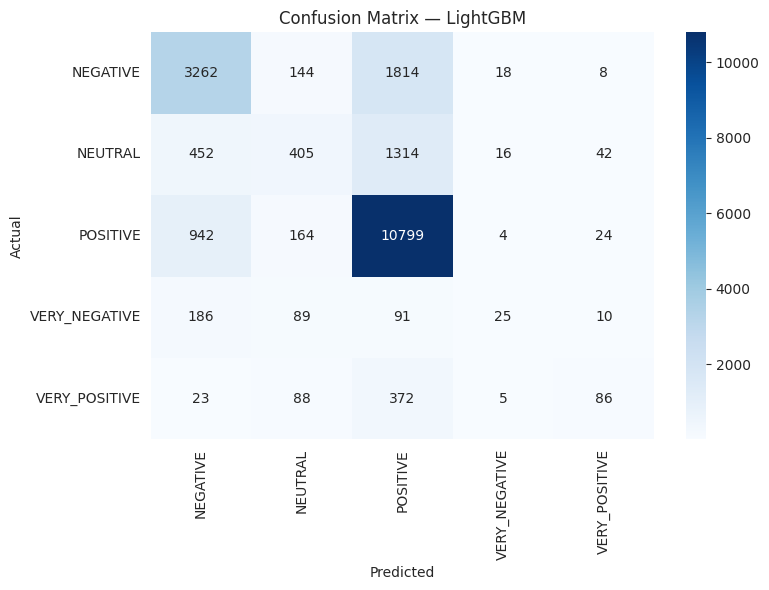

Macro AUC: 0.8167  95% CI [0.8103, 0.8235]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/04_leave_one_aspect_out/05_efficacy_cost_only/outputs_text_only/LightGBM_roc_curve.png


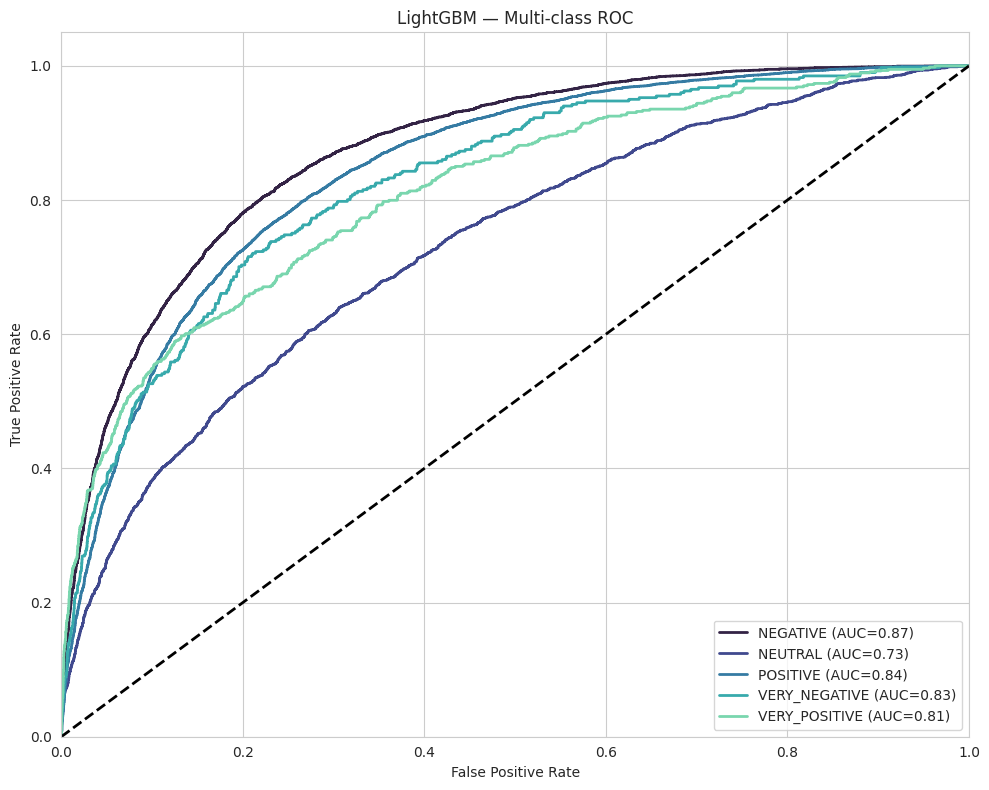

In [ ]:
evaluate_ml(best_model_lgbm, X_test_tfidf, y_test_ml, "LightGBM")

### Step 3: Model Interpretation

Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/04_leave_one_aspect_out/05_efficacy_cost_only/outputs_text_only/lightgbm_feature_importance.png


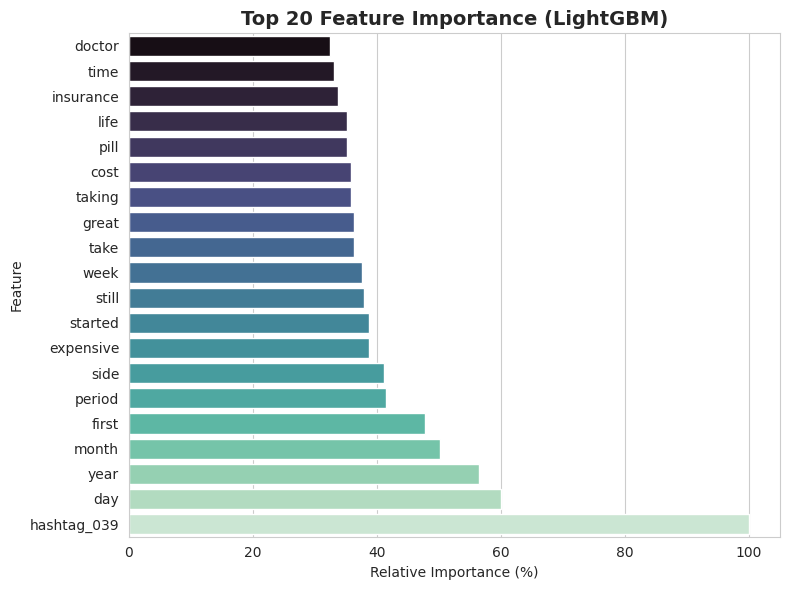

,Feature,Importance,Scaled
4383,hashtag_039,287,100.000000
2727,day,172,59.930314
9920,year,162,56.445993
5880,month,144,50.174216
3843,first,137,47.735192
6609,period,119,41.463415
8061,side,118,41.114983
3626,expensive,111,38.675958
8450,started,111,38.675958
8497,still,109,37.979094


In [ ]:
plot_feature_importance(best_model_lgbm.feature_importances_, feature_names_tfidf, "LightGBM")

## 3.4 Save Predictions for Machine Learning Models

In [ ]:
print("\nSaving ML predictions...")

y_true_str = df_test_ml[LABEL_COLUMN].astype(str).values
y_true_id  = label_encoder.transform(y_true_str)

lr_pred   = best_model_lr.predict(X_test_tfidf)
rf_pred   = best_model_rf.predict(X_test_tfidf)
lgbm_pred = best_model_lgbm.predict(X_test_tfidf)

lr_proba   = best_model_lr.predict_proba(X_test_tfidf)
rf_proba   = best_model_rf.predict_proba(X_test_tfidf)
lgbm_proba = best_model_lgbm.predict_proba(X_test_tfidf)

class_names_ml = best_model_lr.classes_
assert np.array_equal(class_names_ml, best_model_rf.classes_)
assert np.array_equal(class_names_ml, best_model_lgbm.classes_)

# Build prediction DataFrame
if "id" in df_test_ml.columns:
    df_pred_ml = df_test_ml[["id", TEXT_COLUMN]].copy()
else:
    df_pred_ml = df_test_ml[[TEXT_COLUMN]].copy()
    df_pred_ml.insert(0, "id", df_test_ml.index)

df_pred_ml["true_label"]    = y_true_str
df_pred_ml["true_label_id"] = y_true_id
df_pred_ml["lr_pred"]       = lr_pred
df_pred_ml["rf_pred"]       = rf_pred
df_pred_ml["lgbm_pred"]     = lgbm_pred

for i, cls in enumerate(class_names_ml):
    df_pred_ml[f"lr_prob_{cls}"]   = lr_proba[:, i]
    df_pred_ml[f"rf_prob_{cls}"]   = rf_proba[:, i]
    df_pred_ml[f"lgbm_prob_{cls}"] = lgbm_proba[:, i]

ml_pred_path = OUTPUT_PATH / "ml_models_predictions.csv"
df_pred_ml.to_csv(ml_pred_path, index=False)
print(f"Saved ML predictions → {ml_pred_path}")


Saving ML predictions...
Saved ML predictions → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/04_leave_one_aspect_out/05_efficacy_cost_only/outputs_text_only/ml_models_predictions.csv


# 4. DL Models


## 4.0 Pre-processing \& data preparation for DL Models

In [ ]:
df_train_dl = df_clean[df_clean["split"] == "train"].copy()
df_val_dl   = df_clean[df_clean["split"] == "val"].copy()
df_test_dl  = df_clean[df_clean["split"] == "test"].copy()

train_labels_dl = df_train_dl[LABEL_COLUMN_ENCODED].tolist()
val_labels_dl   = df_val_dl[LABEL_COLUMN_ENCODED].tolist()
test_labels_dl  = df_test_dl[LABEL_COLUMN_ENCODED].tolist()

# ── GRU/CNN and Transformers all use review text ──
train_texts_dl = df_train_dl[TEXT_COLUMN].fillna("").astype(str).tolist()
val_texts_dl   = df_val_dl[TEXT_COLUMN].fillna("").astype(str).tolist()
test_texts_dl  = df_test_dl[TEXT_COLUMN].fillna("").astype(str).tolist()

print(f"DL splits: train={len(train_texts_dl)}, val={len(val_texts_dl)}, test={len(test_texts_dl)}")

# ── Build shared vocabulary (GRU + CNN — from review text) ──
# PAD=0, UNK=1, words start at 2
vocab_counter = Counter()
for text in train_texts_dl:
    vocab_counter.update(text.split())
most_common = [w for w, _ in vocab_counter.most_common(VOCAB_SIZE - 2)]  # -2 for PAD and UNK
word_to_index = {w: i + 2 for i, w in enumerate(most_common)}  # 0=PAD, 1=UNK
UNK_IDX = 1

print(f"Vocabulary: {len(word_to_index)} words + PAD(0) + UNK(1)")


def text_to_sequence(text, w2i, max_len=MAX_TOKEN_LENGTH):
    tokens = text.split()
    return [w2i.get(w, UNK_IDX) for w in tokens][:max_len]


# ── Convert & pad sequences (fixed length = MAX_TOKEN_LENGTH) ──
def build_padded_sequences(texts, w2i, max_len=MAX_TOKEN_LENGTH):
    seqs = []
    for t in texts:
        seq = text_to_sequence(t, w2i, max_len)
        # Pad to exactly max_len (not max-in-split)
        padded = seq + [0] * (max_len - len(seq))
        seqs.append(padded)
    return torch.tensor(seqs, dtype=torch.long)


train_seqs = build_padded_sequences(train_texts_dl, word_to_index)
val_seqs   = build_padded_sequences(val_texts_dl, word_to_index)
test_seqs  = build_padded_sequences(test_texts_dl, word_to_index)

train_labels_t = torch.tensor(train_labels_dl, dtype=torch.long)
val_labels_t   = torch.tensor(val_labels_dl, dtype=torch.long)
test_labels_t  = torch.tensor(test_labels_dl, dtype=torch.long)

print(f"Sequence shapes: train={train_seqs.shape}, val={val_seqs.shape}, test={test_seqs.shape}")

DL splits: train=61309, val=20369, test=20383
Vocabulary: 9998 words + PAD(0) + UNK(1)
Sequence shapes: train=torch.Size([61309, 200]), val=torch.Size([20369, 200]), test=torch.Size([20383, 200])


In [ ]:
# ── Dataset class (GRU + CNN) ────────────────────────────
class SeqDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {"input_ids": self.sequences[idx], "label": self.labels[idx]}


# ── DataLoaders (shared, with pin_memory) ────────────────
_loader_kw = dict(batch_size=BATCH_SIZE, num_workers=2,
                  pin_memory=True, persistent_workers=True)

train_loader_seq = DataLoader(SeqDataset(train_seqs, train_labels_t), shuffle=True, **_loader_kw)
val_loader_seq   = DataLoader(SeqDataset(val_seqs, val_labels_t), shuffle=False, **_loader_kw)
test_loader_seq  = DataLoader(SeqDataset(test_seqs, test_labels_t), shuffle=False, **_loader_kw)

# ── Class weights for DL training ────────────────────────
_cw = compute_class_weight("balanced", classes=np.unique(train_labels_dl), y=train_labels_dl)
class_weights_dl = torch.tensor(_cw, dtype=torch.float32).to(DEVICE)

## 4.1 Neural Network (GRU \& CNN)

### 4.1.1 Generic train + evaluation

In [ ]:
def train_seq_model(model, train_loader, val_loader, lr=1e-3,
                    max_epochs=20, patience=5):
    """Train a sequence model (GRU or CNN) with early stopping."""
    model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights_dl)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scaler = GradScaler(enabled=USE_FP16)

    best_f1, best_state, no_improve = -1.0, None, 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        losses = []
        for batch in train_loader:
            ids = batch["input_ids"].to(DEVICE, non_blocking=True)
            labels = batch["label"].to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with autocast("cuda", enabled=USE_FP16):
                logits = model(ids)
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), SEQ_MAX_GRAD_NORM)
            scaler.step(optimizer)
            scaler.update()
            losses.append(loss.item())

        # Validate
        model.eval()
        val_preds, val_true = [], []
        with torch.no_grad():
            for batch in val_loader:
                ids = batch["input_ids"].to(DEVICE, non_blocking=True)
                labels = batch["label"]
                with autocast("cuda", enabled=USE_FP16):
                    logits = model(ids)
                val_preds.extend(logits.float().argmax(dim=1).cpu().numpy())
                val_true.extend(labels.numpy())

        val_f1 = f1_score(val_true, val_preds, average="weighted")
        val_acc = accuracy_score(val_true, val_preds)
        print(f"  Epoch {epoch}/{max_epochs} | Loss={np.mean(losses):.4f} | "
              f"Val F1={val_f1:.4f} | Val Acc={val_acc:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch}.")
                break

    if best_state:
        model.load_state_dict(best_state)
    return best_f1, model

### 4.1.2 GRU

#### Step 1: Define GRU Model

In [ ]:
class GRUSentimentModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.gru = nn.GRU(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids):
        embedded = self.embedding(input_ids)
        _, hidden = self.gru(embedded)
        return self.fc(self.dropout(hidden[-1]))

#### Step 2: Hyperparameter Tuning

In [ ]:
RETRAIN = True
if RETRAIN:
    set_seed()
    print("\nTuning GRU...")
    start = time.time()

    MAX_EPOCHS_GRU = 20
    PATIENCE_GRU = 5

    gru_param_space = {
    "embedding_dim": (128, 256),      # was (150, 300), best=170
    "hidden_dim": (256, 512),          # was (128, 384), best=355
    "lr": (np.log10(5e-4), np.log10(1e-2)),  # narrow around best=8.6e-4
    }

    best_f1_gru, best_params_gru, best_gru = 0, None, None

    for i in tqdm(range(N_ITERATIONS), desc="GRU Random Search"):
        hp = {
            "embedding_dim": int(np.random.uniform(*gru_param_space["embedding_dim"])),
            "hidden_dim": int(np.random.uniform(*gru_param_space["hidden_dim"])),
            "lr": float(10 ** np.random.uniform(*gru_param_space["lr"])),
        }

        model = GRUSentimentModel(
            vocab_size=VOCAB_SIZE, embedding_dim=hp["embedding_dim"],
            hidden_dim=hp["hidden_dim"], output_dim=NUM_CLASSES,
        )

        f1_val, model = train_seq_model(
            model, train_loader_seq, val_loader_seq,
            lr=hp["lr"], max_epochs=MAX_EPOCHS_GRU, patience=PATIENCE_GRU,
        )

        if f1_val > best_f1_gru:
            best_f1_gru = f1_val
            best_params_gru = hp
            best_gru = model

    print(f"GRU tuning: {time.time()-start:.1f}s | Best F1={best_f1_gru:.4f}")
    print(f"Best params: {best_params_gru}")

    torch.save(best_gru.state_dict(), MODEL_PATHS["gru"]["model"])
    with open(MODEL_PATHS["gru"]["params"], "w") as f:
        json.dump(best_params_gru, f, indent=2)
else:
    print("Loading GRU from disk...")
    with open(MODEL_PATHS["gru"]["params"]) as f:
        best_params_gru = json.load(f)
    best_gru = GRUSentimentModel(
        vocab_size=VOCAB_SIZE, embedding_dim=int(best_params_gru["embedding_dim"]),
        hidden_dim=int(best_params_gru["hidden_dim"]), output_dim=NUM_CLASSES,
    )
    best_gru.load_state_dict(torch.load(MODEL_PATHS["gru"]["model"], map_location=DEVICE))
    print(f"Loaded GRU from {MODEL_PATHS['gru']['model']}")



Tuning GRU...


GRU Random Search:   0%|          | 0/10 [00:00<?, ?it/s]

  Epoch 1/20 | Loss=1.7493 | Val F1=0.0952 | Val Acc=0.0820
  Epoch 2/20 | Loss=2.0941 | Val F1=0.2947 | Val Acc=0.2679
  Epoch 3/20 | Loss=7.6030 | Val F1=0.1038 | Val Acc=0.2552
  Epoch 4/20 | Loss=23.5726 | Val F1=0.0015 | Val Acc=0.0186
  Epoch 5/20 | Loss=24.9409 | Val F1=0.0015 | Val Acc=0.0186
  Epoch 6/20 | Loss=24.9219 | Val F1=0.0015 | Val Acc=0.0186


GRU Random Search:  10%|█         | 1/10 [00:28<04:14, 28.26s/it]

  Epoch 7/20 | Loss=24.9783 | Val F1=0.0015 | Val Acc=0.0186
  Early stopping at epoch 7.
  Epoch 1/20 | Loss=1.6109 | Val F1=0.4319 | Val Acc=0.5843
  Epoch 2/20 | Loss=1.6076 | Val F1=0.4322 | Val Acc=0.5844
  Epoch 3/20 | Loss=1.6069 | Val F1=0.0231 | Val Acc=0.1115
  Epoch 4/20 | Loss=1.6066 | Val F1=0.4321 | Val Acc=0.5846
  Epoch 5/20 | Loss=1.6067 | Val F1=0.4322 | Val Acc=0.5849
  Epoch 6/20 | Loss=1.6066 | Val F1=0.0233 | Val Acc=0.1116
  Epoch 7/20 | Loss=1.6065 | Val F1=0.0237 | Val Acc=0.1119
  Epoch 8/20 | Loss=1.6062 | Val F1=0.1052 | Val Acc=0.2556
  Epoch 9/20 | Loss=1.6062 | Val F1=0.0068 | Val Acc=0.0326
  Epoch 10/20 | Loss=1.6038 | Val F1=0.4379 | Val Acc=0.4086
  Epoch 11/20 | Loss=1.3046 | Val F1=0.5742 | Val Acc=0.5457
  Epoch 12/20 | Loss=0.9992 | Val F1=0.6378 | Val Acc=0.6176
  Epoch 13/20 | Loss=0.7354 | Val F1=0.5833 | Val Acc=0.5479
  Epoch 14/20 | Loss=0.5470 | Val F1=0.5627 | Val Acc=0.5174
  Epoch 15/20 | Loss=0.4320 | Val F1=0.5968 | Val Acc=0.5676
  Ep

...

  Epoch 20/20 | Loss=0.1922 | Val F1=0.6620 | Val Acc=0.6500
  Epoch 1/20 | Loss=1.6184 | Val F1=0.4349 | Val Acc=0.4578
  Epoch 2/20 | Loss=1.4945 | Val F1=0.5355 | Val Acc=0.5198
  Epoch 3/20 | Loss=1.1572 | Val F1=0.6321 | Val Acc=0.6048
  Epoch 4/20 | Loss=0.8667 | Val F1=0.5473 | Val Acc=0.4975
  Epoch 5/20 | Loss=0.6280 | Val F1=0.6172 | Val Acc=0.5827
  Epoch 6/20 | Loss=0.4778 | Val F1=0.6396 | Val Acc=0.6086
  Epoch 7/20 | Loss=0.3732 | Val F1=0.6765 | Val Acc=0.6653
  Epoch 8/20 | Loss=0.2921 | Val F1=0.6578 | Val Acc=0.6422
  Epoch 9/20 | Loss=0.2306 | Val F1=0.6645 | Val Acc=0.6458
  Epoch 10/20 | Loss=0.1923 | Val F1=0.6594 | Val Acc=0.6403
  Epoch 11/20 | Loss=0.1503 | Val F1=0.6643 | Val Acc=0.6528


GRU Random Search:  90%|█████████ | 9/10 [06:29<00:48, 48.60s/it]

  Epoch 12/20 | Loss=0.1515 | Val F1=0.6749 | Val Acc=0.6657
  Early stopping at epoch 12.
  Epoch 1/20 | Loss=1.6103 | Val F1=0.4319 | Val Acc=0.5843
  Epoch 2/20 | Loss=1.6078 | Val F1=0.1042 | Val Acc=0.2551
  Epoch 3/20 | Loss=1.6070 | Val F1=0.0232 | Val Acc=0.1116
  Epoch 4/20 | Loss=1.6067 | Val F1=0.4320 | Val Acc=0.5847
  Epoch 5/20 | Loss=1.6062 | Val F1=0.4320 | Val Acc=0.5846
  Epoch 6/20 | Loss=1.6063 | Val F1=0.1051 | Val Acc=0.2555
  Epoch 7/20 | Loss=1.6060 | Val F1=0.1048 | Val Acc=0.2554
  Epoch 8/20 | Loss=1.6060 | Val F1=0.4320 | Val Acc=0.5847
  Epoch 9/20 | Loss=1.6060 | Val F1=0.0236 | Val Acc=0.1118
  Epoch 10/20 | Loss=1.6056 | Val F1=0.4321 | Val Acc=0.5847
  Epoch 11/20 | Loss=1.6056 | Val F1=0.1047 | Val Acc=0.2554
  Epoch 12/20 | Loss=1.6057 | Val F1=0.1051 | Val Acc=0.2555
  Epoch 13/20 | Loss=1.6058 | Val F1=0.0238 | Val Acc=0.1119
  Epoch 14/20 | Loss=1.6059 | Val F1=0.4321 | Val Acc=0.5847


GRU Random Search: 100%|██████████| 10/10 [07:21<00:00, 44.15s/it]

  Epoch 15/20 | Loss=1.6062 | Val F1=0.4321 | Val Acc=0.5845
  Early stopping at epoch 15.
GRU tuning: 441.5s | Best F1=0.6765
Best params: {'embedding_dim': 245, 'hidden_dim': 498, 'lr': 0.001148848116906648}


#### Step 3: Model Evaluation

Eval GRU: 100%|██████████| 160/160 [00:00<00:00, 378.42it/s]



Evaluation: GRU
               precision    recall  f1-score   support

VERY_NEGATIVE     0.2027    0.2968    0.2409       401
     NEGATIVE     0.6164    0.6763    0.6450      5246
      NEUTRAL     0.2809    0.3275    0.3024      2229
     POSITIVE     0.8173    0.7275    0.7698     11933
VERY_POSITIVE     0.2488    0.3554    0.2927       574

     accuracy                         0.6516     20383
    macro avg     0.4332    0.4767    0.4501     20383
 weighted avg     0.6789    0.6516    0.6627     20383

Weighted F1: 0.6627  95% CI [0.6563, 0.6690]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/04_leave_one_aspect_out/05_efficacy_cost_only/outputs_text_only/GRU_confusion_matrix.png


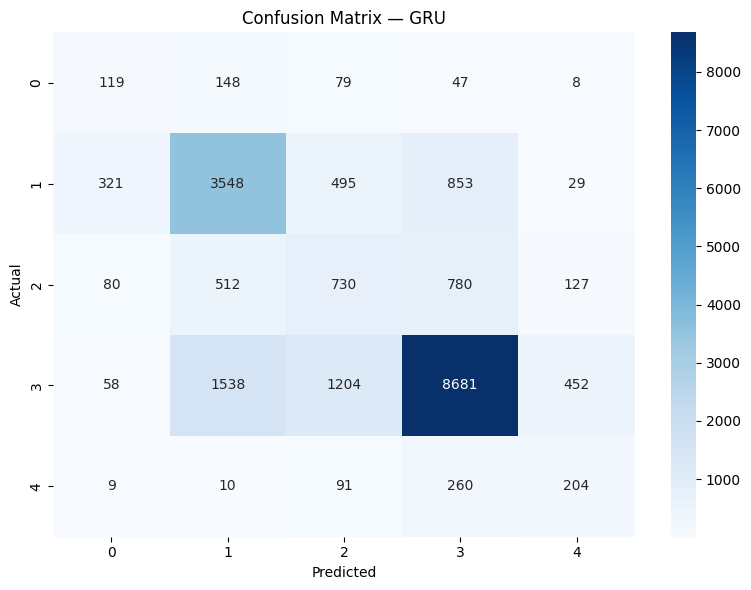

Macro AUC: 0.8171  95% CI [0.8113, 0.8228]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/04_leave_one_aspect_out/05_efficacy_cost_only/outputs_text_only/GRU_roc_curve.png


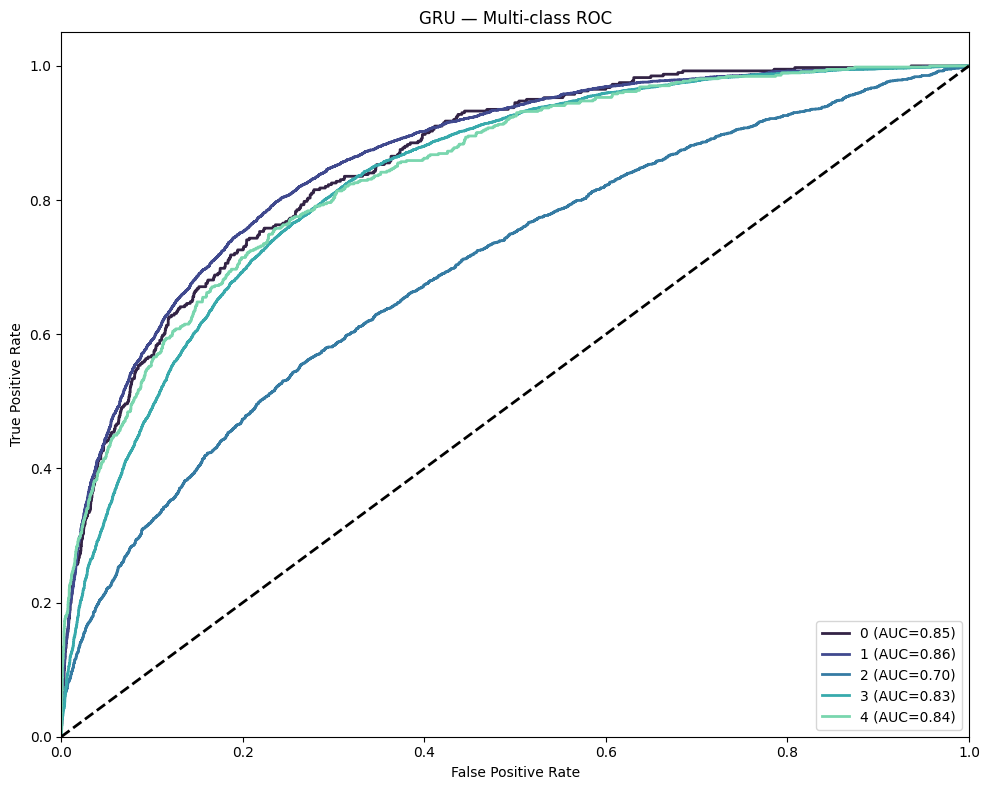

In [ ]:
gru_preds, gru_probs, y_true_gru = evaluate_pytorch(
    best_gru, test_loader_seq, label_encoder, "GRU", use_attention_mask=False
)

### 4.1.3 CNN

### 4.2.2 CNN Modeling

#### Step 1: Define CNN Model

In [ ]:
class CNNSentimentModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_filters, filter_sizes,
                 output_dim, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(embedding_dim, num_filters, fs) for fs in filter_sizes
        ])
        self.fc = nn.Linear(num_filters * len(filter_sizes), output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids):
        x = self.embedding(input_ids).permute(0, 2, 1)  # [B, E, L]
        pooled = [torch.relu(conv(x)).max(dim=2).values for conv in self.convs]
        cat = torch.cat(pooled, dim=1)
        return self.fc(self.dropout(cat))

#### Step 2: Hyperparameter Tuning

In [ ]:
RETRAIN = True

FILTER_SIZES = [3, 4, 5]

if RETRAIN:
    set_seed()
    print("\nTuning CNN...")
    start = time.time()

    MAX_EPOCHS_CNN = 20
    PATIENCE_CNN = 5

    cnn_param_space = {
        "embedding_dim": (150, 300),
        "num_filters": (64, 256),
        "lr": (np.log10(1e-4), np.log10(1e-3)),
    }

    best_f1_cnn, best_params_cnn, best_cnn = 0, None, None

    for i in tqdm(range(N_ITERATIONS), desc="CNN Random Search"):
        hp = {
            "embedding_dim": int(np.random.uniform(*cnn_param_space["embedding_dim"])),
            "num_filters": int(np.random.uniform(*cnn_param_space["num_filters"])),
            "lr": float(10 ** np.random.uniform(*cnn_param_space["lr"])),
        }

        model = CNNSentimentModel(
            vocab_size=VOCAB_SIZE, embedding_dim=hp["embedding_dim"],
            num_filters=hp["num_filters"], filter_sizes=FILTER_SIZES,
            output_dim=NUM_CLASSES,
        )

        f1_val, model = train_seq_model(
            model, train_loader_seq, val_loader_seq,
            lr=hp["lr"], max_epochs=MAX_EPOCHS_CNN, patience=PATIENCE_CNN,
        )

        if f1_val > best_f1_cnn:
            best_f1_cnn = f1_val
            best_params_cnn = hp
            best_cnn = model

    print(f"CNN tuning: {time.time()-start:.1f}s | Best F1={best_f1_cnn:.4f}")
    print(f"Best params: {best_params_cnn}")

    torch.save(best_cnn.state_dict(), MODEL_PATHS["cnn"]["model"])
    with open(MODEL_PATHS["cnn"]["params"], "w") as f:
        json.dump(best_params_cnn, f, indent=2)
else:
    print("Loading CNN from disk...")
    with open(MODEL_PATHS["cnn"]["params"]) as f:
        best_params_cnn = json.load(f)
    best_cnn = CNNSentimentModel(
        vocab_size=VOCAB_SIZE, embedding_dim=int(best_params_cnn["embedding_dim"]),
        num_filters=int(best_params_cnn["num_filters"]), filter_sizes=FILTER_SIZES,
        output_dim=NUM_CLASSES,
    )
    best_cnn.load_state_dict(torch.load(MODEL_PATHS["cnn"]["model"], map_location=DEVICE))
    print(f"Loaded CNN from {MODEL_PATHS['cnn']['model']}")


Tuning CNN...


CNN Random Search:   0%|          | 0/10 [00:00<?, ?it/s]

  Epoch 1/20 | Loss=1.6001 | Val F1=0.4693 | Val Acc=0.3980
  Epoch 2/20 | Loss=1.2704 | Val F1=0.5980 | Val Acc=0.5581
  Epoch 3/20 | Loss=1.0996 | Val F1=0.6523 | Val Acc=0.6287
  Epoch 4/20 | Loss=0.9411 | Val F1=0.6329 | Val Acc=0.5999
  Epoch 5/20 | Loss=0.7985 | Val F1=0.5848 | Val Acc=0.5664
  Epoch 6/20 | Loss=0.6671 | Val F1=0.6667 | Val Acc=0.6440
  Epoch 7/20 | Loss=0.5550 | Val F1=0.6236 | Val Acc=0.5910
  Epoch 8/20 | Loss=0.4649 | Val F1=0.6695 | Val Acc=0.6514
  Epoch 9/20 | Loss=0.3797 | Val F1=0.6680 | Val Acc=0.6456
  Epoch 10/20 | Loss=0.3135 | Val F1=0.6831 | Val Acc=0.6803
  Epoch 11/20 | Loss=0.2664 | Val F1=0.6960 | Val Acc=0.7017
  Epoch 12/20 | Loss=0.2416 | Val F1=0.6916 | Val Acc=0.6890
  Epoch 13/20 | Loss=0.2115 | Val F1=0.6857 | Val Acc=0.6805
  Epoch 14/20 | Loss=0.1920 | Val F1=0.6955 | Val Acc=0.7017
  Epoch 15/20 | Loss=0.1764 | Val F1=0.6854 | Val Acc=0.6851
  Epoch 16/20 | Loss=0.1637 | Val F1=0.6969 | Val Acc=0.7147
  Epoch 17/20 | Loss=0.1471 | Val

CNN Random Search:  10%|█         | 1/10 [00:27<04:08, 27.61s/it]

  Epoch 20/20 | Loss=0.1387 | Val F1=0.6948 | Val Acc=0.7136
  Epoch 1/20 | Loss=1.6282 | Val F1=0.5732 | Val Acc=0.5575
  Epoch 2/20 | Loss=1.4043 | Val F1=0.4643 | Val Acc=0.4037
  Epoch 3/20 | Loss=1.2523 | Val F1=0.6065 | Val Acc=0.5868
  Epoch 4/20 | Loss=1.1492 | Val F1=0.6132 | Val Acc=0.5805
  Epoch 5/20 | Loss=1.0512 | Val F1=0.5933 | Val Acc=0.5592
  Epoch 6/20 | Loss=0.9801 | Val F1=0.6442 | Val Acc=0.6227
  Epoch 7/20 | Loss=0.9165 | Val F1=0.6428 | Val Acc=0.6211
  Epoch 8/20 | Loss=0.8565 | Val F1=0.6317 | Val Acc=0.6151
  Epoch 9/20 | Loss=0.8019 | Val F1=0.6304 | Val Acc=0.6033
  Epoch 10/20 | Loss=0.7504 | Val F1=0.6591 | Val Acc=0.6429
  Epoch 11/20 | Loss=0.7167 | Val F1=0.6610 | Val Acc=0.6488
  Epoch 12/20 | Loss=0.6758 | Val F1=0.6485 | Val Acc=0.6272
  Epoch 13/20 | Loss=0.6444 | Val F1=0.6846 | Val Acc=0.6799
  Epoch 14/20 | Loss=0.6050 | Val F1=0.6630 | Val Acc=0.6409
  Epoch 15/20 | Loss=0.5696 | Val F1=0.6560 | Val Acc=0.6369
  Epoch 16/20 | Loss=0.5455 | Val

...

  Epoch 20/20 | Loss=0.4038 | Val F1=0.7146 | Val Acc=0.7182
  Epoch 1/20 | Loss=1.6008 | Val F1=0.5597 | Val Acc=0.5275
  Epoch 2/20 | Loss=1.2994 | Val F1=0.5923 | Val Acc=0.5678
  Epoch 3/20 | Loss=1.1235 | Val F1=0.6524 | Val Acc=0.6343
  Epoch 4/20 | Loss=0.9956 | Val F1=0.5333 | Val Acc=0.4876
  Epoch 5/20 | Loss=0.8747 | Val F1=0.6187 | Val Acc=0.5881
  Epoch 6/20 | Loss=0.7861 | Val F1=0.6623 | Val Acc=0.6449
  Epoch 7/20 | Loss=0.7124 | Val F1=0.5837 | Val Acc=0.5520
  Epoch 8/20 | Loss=0.6453 | Val F1=0.6862 | Val Acc=0.6727
  Epoch 9/20 | Loss=0.5926 | Val F1=0.6679 | Val Acc=0.6599
  Epoch 10/20 | Loss=0.5398 | Val F1=0.7014 | Val Acc=0.6949
  Epoch 11/20 | Loss=0.4967 | Val F1=0.7081 | Val Acc=0.7099
  Epoch 12/20 | Loss=0.4591 | Val F1=0.6893 | Val Acc=0.6818
  Epoch 13/20 | Loss=0.4208 | Val F1=0.7150 | Val Acc=0.7230
  Epoch 14/20 | Loss=0.3924 | Val F1=0.7140 | Val Acc=0.7167
  Epoch 15/20 | Loss=0.3619 | Val F1=0.7182 | Val Acc=0.7223
  Epoch 16/20 | Loss=0.3241 | Val

CNN Random Search:  90%|█████████ | 9/10 [03:35<00:24, 24.87s/it]

  Epoch 20/20 | Loss=0.2204 | Val F1=0.7165 | Val Acc=0.7260
  Epoch 1/20 | Loss=1.6771 | Val F1=0.4794 | Val Acc=0.4243
  Epoch 2/20 | Loss=1.5185 | Val F1=0.5071 | Val Acc=0.4655
  Epoch 3/20 | Loss=1.4049 | Val F1=0.5595 | Val Acc=0.5362
  Epoch 4/20 | Loss=1.3160 | Val F1=0.6186 | Val Acc=0.6063
  Epoch 5/20 | Loss=1.2416 | Val F1=0.5710 | Val Acc=0.5442
  Epoch 6/20 | Loss=1.1851 | Val F1=0.5812 | Val Acc=0.5441
  Epoch 7/20 | Loss=1.1325 | Val F1=0.6119 | Val Acc=0.5834
  Epoch 8/20 | Loss=1.0848 | Val F1=0.6275 | Val Acc=0.6073
  Epoch 9/20 | Loss=1.0422 | Val F1=0.6323 | Val Acc=0.6117
  Epoch 10/20 | Loss=0.9961 | Val F1=0.5952 | Val Acc=0.5612
  Epoch 11/20 | Loss=0.9691 | Val F1=0.6243 | Val Acc=0.5974
  Epoch 12/20 | Loss=0.9344 | Val F1=0.6278 | Val Acc=0.6060
  Epoch 13/20 | Loss=0.9108 | Val F1=0.6457 | Val Acc=0.6240
  Epoch 14/20 | Loss=0.8676 | Val F1=0.6699 | Val Acc=0.6615
  Epoch 15/20 | Loss=0.8477 | Val F1=0.6535 | Val Acc=0.6406
  Epoch 16/20 | Loss=0.8287 | Val

CNN Random Search: 100%|██████████| 10/10 [03:57<00:00, 23.72s/it]

  Epoch 19/20 | Loss=0.7516 | Val F1=0.6678 | Val Acc=0.6537
  Early stopping at epoch 19.
CNN tuning: 237.2s | Best F1=0.7183
Best params: {'embedding_dim': 287, 'num_filters': 245, 'lr': 0.00018953847119167257}


#### Step 3: Model Evaluation

Eval CNN: 100%|██████████| 160/160 [00:00<00:00, 250.96it/s]



Evaluation: CNN
               precision    recall  f1-score   support

VERY_NEGATIVE     0.4855    0.1671    0.2486       401
     NEGATIVE     0.6811    0.7160    0.6981      5246
      NEUTRAL     0.3475    0.3369    0.3421      2229
     POSITIVE     0.8047    0.8289    0.8166     11933
VERY_POSITIVE     0.5000    0.2422    0.3263       574

     accuracy                         0.7165     20383
    macro avg     0.5638    0.4582    0.4863     20383
 weighted avg     0.7080    0.7165    0.7092     20383

Weighted F1: 0.7093  95% CI [0.7027, 0.7155]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/04_leave_one_aspect_out/05_efficacy_cost_only/outputs_text_only/CNN_confusion_matrix.png


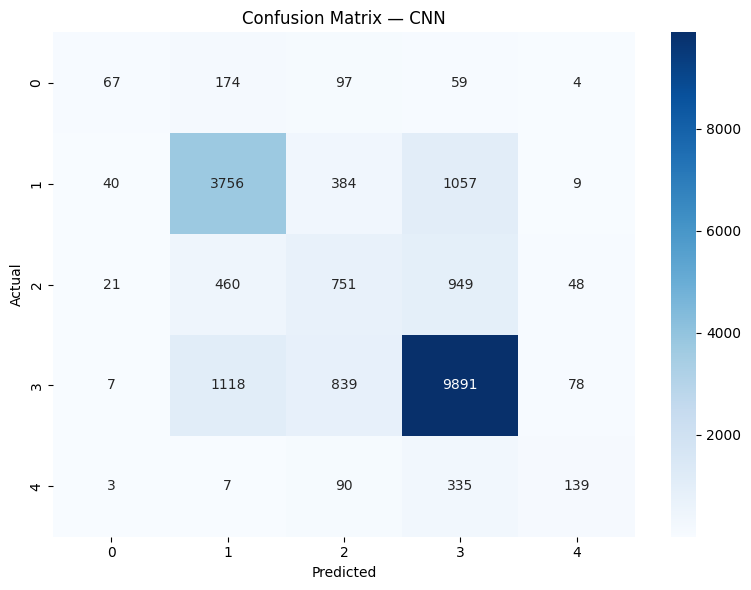

Macro AUC: 0.8423  95% CI [0.8363, 0.8480]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/04_leave_one_aspect_out/05_efficacy_cost_only/outputs_text_only/CNN_roc_curve.png


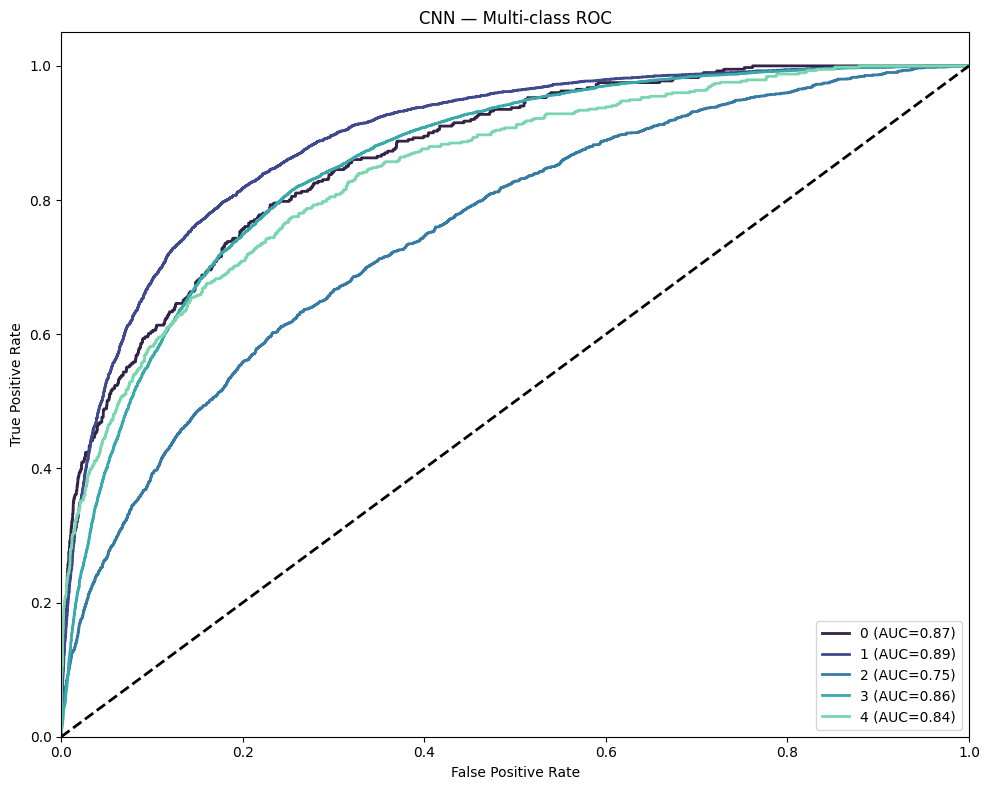

In [ ]:
cnn_preds, cnn_probs, y_true_cnn = evaluate_pytorch(
    best_cnn, test_loader_seq, label_encoder, "CNN", use_attention_mask=False
)

## 4.2 Transformer

### 4.2.1 Generic transformer train function

In [ ]:
def train_transformer(model, train_loader, val_loader,
                      lr=2e-5, max_epochs=6, patience=2):
    """Fine-tune a HuggingFace transformer with FP16, grad clip, OneCycleLR."""
    model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    total_steps = max_epochs * len(train_loader)
    scheduler = OneCycleLR(optimizer, max_lr=lr, total_steps=total_steps, pct_start=0.1)
    criterion = nn.CrossEntropyLoss(weight=class_weights_dl)
    scaler = GradScaler(enabled=USE_FP16)

    best_f1, best_state, no_improve = -1.0, None, 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        losses = []
        for batch in train_loader:
            ids  = batch["input_ids"].to(DEVICE, non_blocking=True)
            mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
            labels = batch["label"].to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with autocast("cuda", enabled=USE_FP16):
                outputs = model(input_ids=ids, attention_mask=mask)
                logits = outputs.logits if hasattr(outputs, "logits") else outputs
                loss = criterion(logits, labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            losses.append(loss.item())

        # Validate
        model.eval()
        val_preds, val_true = [], []
        with torch.no_grad():
            for batch in val_loader:
                ids  = batch["input_ids"].to(DEVICE, non_blocking=True)
                mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
                with autocast("cuda", enabled=USE_FP16):
                    out = model(input_ids=ids, attention_mask=mask)
                logits = out.logits if hasattr(out, "logits") else out
                val_preds.extend(logits.float().argmax(dim=1).cpu().numpy())
                val_true.extend(batch["label"].numpy())

        val_f1 = f1_score(val_true, val_preds, average="weighted")
        print(f"  Epoch {epoch}/{max_epochs} | Loss={np.mean(losses):.4f} | Val F1={val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            raw = model._orig_mod if hasattr(model, "_orig_mod") else model
            best_state = {k: v.cpu().clone() for k, v in raw.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch}.")
                break

    raw = model._orig_mod if hasattr(model, "_orig_mod") else model
    if best_state:
        raw.load_state_dict(best_state)
    return best_f1, raw

### 4.2.2 ALBERT

#### Step 1: Data Preparation

In [ ]:
print("\nPre-tokenizing for ALBERT...")
albert_tokenizer = AutoTokenizer.from_pretrained("albert-base-v2")


def batch_tokenize(texts, tokenizer, max_len, batch_size=512):
    all_ids, all_masks = [], []
    for i in range(0, len(texts), batch_size):
        enc = tokenizer(
            texts[i:i+batch_size], max_length=max_len,
            truncation=True, padding="max_length", return_tensors="pt",
        )
        all_ids.append(enc["input_ids"])
        all_masks.append(enc["attention_mask"])
    return torch.cat(all_ids), torch.cat(all_masks)


# Use same text lists as DL
train_ids_albert, train_masks_albert = batch_tokenize(train_texts_dl, albert_tokenizer, MAX_TOKEN_LENGTH)
val_ids_albert, val_masks_albert     = batch_tokenize(val_texts_dl, albert_tokenizer, MAX_TOKEN_LENGTH)
test_ids_albert, test_masks_albert   = batch_tokenize(test_texts_dl, albert_tokenizer, MAX_TOKEN_LENGTH)
print(f"ALBERT tokens: train={train_ids_albert.shape}")


# ── Cached dataset for transformers ──────────────────────
class TransformerDataset(Dataset):
    def __init__(self, input_ids, attention_mask, labels):
        self.input_ids = input_ids
        self.attention_mask = attention_mask
        self.labels = torch.tensor(np.asarray(labels, dtype=np.int64))

    def __len__(self):
        return self.input_ids.shape[0]

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "label": self.labels[idx],
        }


_tf_loader_kw = dict(batch_size=BATCH_SIZE, num_workers=2,
                     pin_memory=True, persistent_workers=True, prefetch_factor=4)

train_loader_albert = DataLoader(
    TransformerDataset(train_ids_albert, train_masks_albert, train_labels_dl),
    shuffle=True, **_tf_loader_kw)
val_loader_albert = DataLoader(
    TransformerDataset(val_ids_albert, val_masks_albert, val_labels_dl),
    shuffle=False, **_tf_loader_kw)
test_loader_albert = DataLoader(
    TransformerDataset(test_ids_albert, test_masks_albert, test_labels_dl),
    shuffle=False, **_tf_loader_kw)


Pre-tokenizing for ALBERT...


config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

ALBERT tokens: train=torch.Size([61309, 200])


#### Step 2: Hyperparameter Tuning

In [ ]:
RETRAIN = True

if RETRAIN:
    set_seed()
    print("\nTuning ALBERT...")
    start = time.time()

    albert_param_space = {
        "lr": (np.log10(1e-5), np.log10(3e-5)),
        "epochs": (4, 10),
        "dropout": (0.0, 0.25),
    }

    best_f1_albert, best_params_albert, best_albert = 0, None, None

    for i in tqdm(range(N_ITERATIONS), desc="ALBERT Random Search"):
        hp = {
            "lr": float(10 ** np.random.uniform(*albert_param_space["lr"])),
            "epochs": int(np.random.randint(*albert_param_space["epochs"])),
            "dropout": float(np.random.uniform(*albert_param_space["dropout"])),
        }

        model = AlbertForSequenceClassification.from_pretrained(
            "albert-base-v2", num_labels=NUM_CLASSES,
            classifier_dropout_prob=hp["dropout"],
        )

        if TORCH_COMPILE_OK:
            model = torch.compile(model, mode="reduce-overhead")

        f1_val, model = train_transformer(
            model, train_loader_albert, val_loader_albert,
            lr=hp["lr"], max_epochs=hp["epochs"], patience=3,
        )

        if f1_val > best_f1_albert:
            best_f1_albert = f1_val
            best_params_albert = hp
            best_albert = model

        del model
        gc.collect()
        torch.cuda.empty_cache()

    print(f"ALBERT tuning: {time.time()-start:.1f}s | Best F1={best_f1_albert:.4f}")
    print(f"Best params: {best_params_albert}")

    torch.save(best_albert.state_dict(), MODEL_PATHS["albert"]["model"])
else:
    print("Loading ALBERT from disk...")
    best_albert = AlbertForSequenceClassification.from_pretrained(
        "albert-base-v2", num_labels=NUM_CLASSES,
    )
    best_albert.load_state_dict(torch.load(MODEL_PATHS["albert"]["model"], map_location=DEVICE))
    print(f"Loaded ALBERT from {MODEL_PATHS['albert']['model']}")


Tuning ALBERT...


ALBERT Random Search:   0%|          | 0/10 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/47.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

AlbertForSequenceClassification LOAD REPORT from: albert-base-v2
Key                          | Status     | 
-----------------------------+------------+-
predictions.bias             | UNEXPECTED | 
predictions.decoder.bias     | UNEXPECTED | 
predictions.dense.weight     | UNEXPECTED | 
predictions.LayerNorm.bias   | UNEXPECTED | 
predictions.LayerNorm.weight | UNEXPECTED | 
predictions.dense.bias       | UNEXPECTED | 
classifier.bias              | MISSING    | 
classifier.weight            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

AlbertForSequenceClassification LOAD REPORT from: albert-base-v2
Key                          | Status     | 
-----------------------------+------------+-
predictions.bias             | UNEXPECTED | 
predictions.decoder.bias     | UNEXPECTED | 
predictions.dense.weight     | UNEXPECTED | 
predictions.LayerNorm.bias   | UNEXPECTED | 
predictions.LayerNorm.weight | UNEXPECTED | 
predictions.dense.bias       | UNEXPECTED | 
classifier.bias              | MISSING    | 
classifier.weight            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/9 | Loss=1.3121 | Val F1=0.7243
  Epoch 2/9 | Loss=0.9211 | Val F1=0.7774
  Epoch 3/9 | Loss=0.7499 | Val F1=0.6689
  Epoch 4/9 | Loss=0.5854 | Val F1=0.7629
  Epoch 5/9 | Loss=0.4108 | Val F1=0.7260
  Early stopping at epoch 5.


ALBERT Random Search: 100%|██████████| 10/10 [1:31:17<00:00, 547.72s/it]

ALBERT tuning: 5477.2s | Best F1=0.7774
Best params: {'lr': 2.9768448441450054e-05, 'epochs': 9, 'dropout': 0.2365358833708563}


#### Step 3: Model Evaluation

Eval ALBERT: 100%|██████████| 160/160 [00:12<00:00, 13.20it/s]



Evaluation: ALBERT
               precision    recall  f1-score   support

VERY_NEGATIVE     0.4436    0.4414    0.4425       401
     NEGATIVE     0.7566    0.7958    0.7757      5246
      NEUTRAL     0.3753    0.5191    0.4356      2229
     POSITIVE     0.8965    0.8186    0.8558     11933
VERY_POSITIVE     0.5585    0.4739    0.5127       574

     accuracy                         0.7628     20383
    macro avg     0.6061    0.6097    0.6045     20383
 weighted avg     0.7851    0.7628    0.7714     20383

Weighted F1: 0.7714  95% CI [0.7656, 0.7767]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/04_leave_one_aspect_out/05_efficacy_cost_only/outputs_text_only/ALBERT_confusion_matrix.png


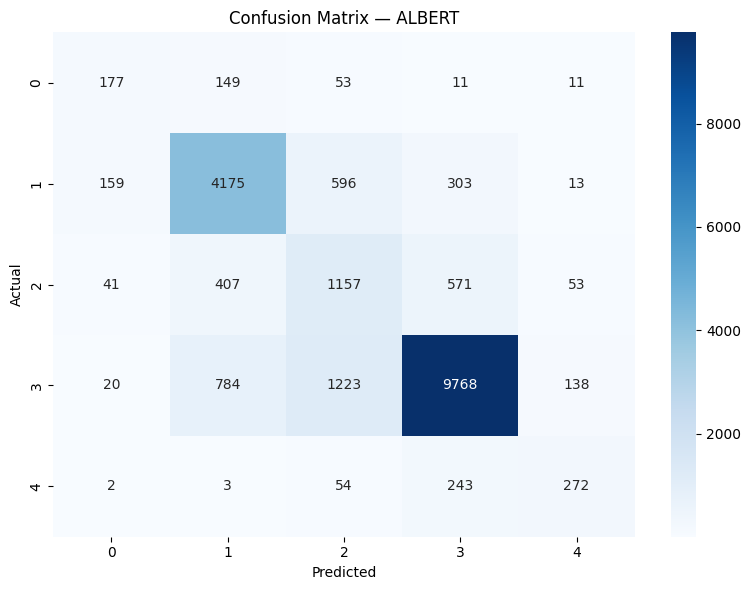

Macro AUC: 0.8990  95% CI [0.8946, 0.9034]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/04_leave_one_aspect_out/05_efficacy_cost_only/outputs_text_only/ALBERT_roc_curve.png


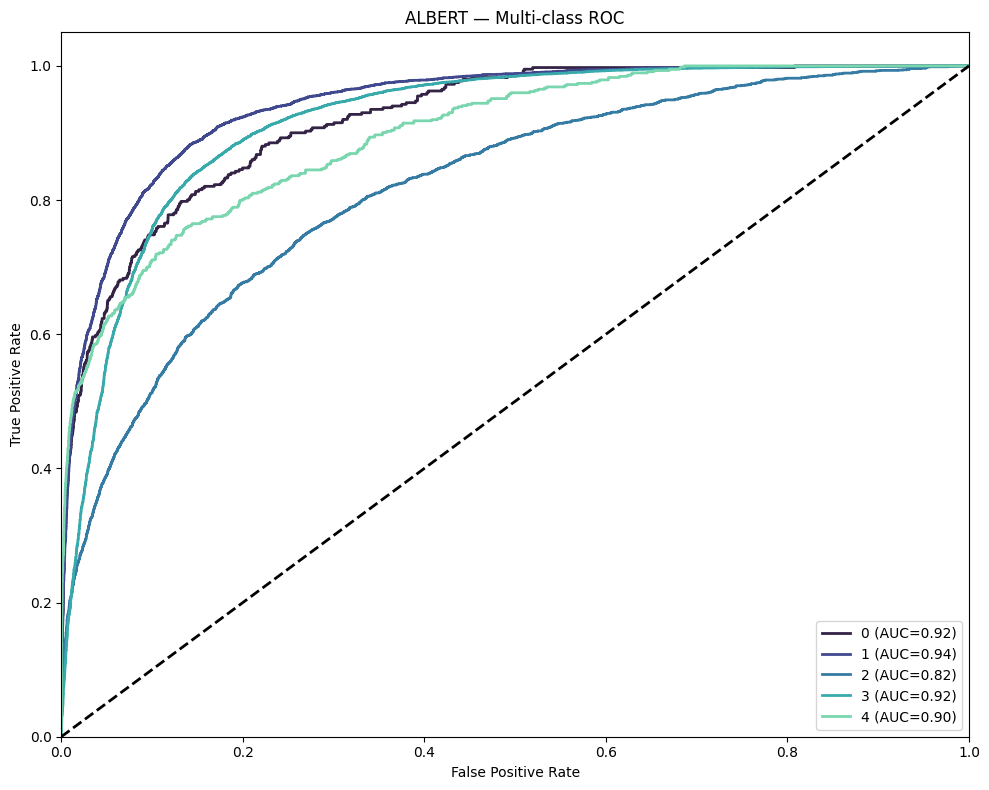

In [ ]:
albert_preds, albert_probs, y_true_albert = evaluate_pytorch(
    best_albert, test_loader_albert, label_encoder, "ALBERT", use_attention_mask=True
)

### 4.4.3 BioBERT Modeling

#### Step 1: Data Preparation

In [ ]:
print("\nPre-tokenizing for BioBERT...")
biobert_name = "dmis-lab/biobert-base-cased-v1.2"
biobert_tokenizer = AutoTokenizer.from_pretrained(biobert_name)

train_ids_bio, train_masks_bio = batch_tokenize(train_texts_dl, biobert_tokenizer, MAX_TOKEN_LENGTH)
val_ids_bio, val_masks_bio     = batch_tokenize(val_texts_dl, biobert_tokenizer, MAX_TOKEN_LENGTH)
test_ids_bio, test_masks_bio   = batch_tokenize(test_texts_dl, biobert_tokenizer, MAX_TOKEN_LENGTH)
print(f"BioBERT tokens: train={train_ids_bio.shape}")

train_loader_biobert = DataLoader(
    TransformerDataset(train_ids_bio, train_masks_bio, train_labels_dl),
    shuffle=True, **_tf_loader_kw)
val_loader_biobert = DataLoader(
    TransformerDataset(val_ids_bio, val_masks_bio, val_labels_dl),
    shuffle=False, **_tf_loader_kw)
test_loader_biobert = DataLoader(
    TransformerDataset(test_ids_bio, test_masks_bio, test_labels_dl),
    shuffle=False, **_tf_loader_kw)


Pre-tokenizing for BioBERT...


config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

BioBERT tokens: train=torch.Size([61309, 200])


#### Step 2: Hyperparameter Tuning

In [ ]:
RETRAIN = True

if RETRAIN:
    set_seed()
    print("\nTuning BioBERT...")
    start = time.time()

    biobert_param_space = {
        "lr": (np.log10(1e-5), np.log10(3e-5)),
        "epochs": (4, 10),
        "dropout": (0.0, 0.25),
    }

    best_f1_biobert, best_params_biobert, best_biobert = 0, None, None

    for i in tqdm(range(N_ITERATIONS), desc="BioBERT Random Search"):
        hp = {
            "lr": float(10 ** np.random.uniform(*biobert_param_space["lr"])),
            "epochs": int(np.random.randint(*biobert_param_space["epochs"])),
            "dropout": float(np.random.uniform(*biobert_param_space["dropout"])),
        }

        model = AutoModelForSequenceClassification.from_pretrained(
            biobert_name, num_labels=NUM_CLASSES,
        )
        model.config.hidden_dropout_prob = hp["dropout"]
        model.config.attention_probs_dropout_prob = hp["dropout"]

        if TORCH_COMPILE_OK:
            model = torch.compile(model, mode="reduce-overhead")

        f1_val, model = train_transformer(
            model, train_loader_biobert, val_loader_biobert,
            lr=hp["lr"], max_epochs=hp["epochs"], patience=3,
        )

        if f1_val > best_f1_biobert:
            best_f1_biobert = f1_val
            best_params_biobert = hp
            best_biobert = model

        del model
        gc.collect()
        torch.cuda.empty_cache()

    print(f"BioBERT tuning: {time.time()-start:.1f}s | Best F1={best_f1_biobert:.4f}")
    print(f"Best params: {best_params_biobert}")

    torch.save(best_biobert.state_dict(), MODEL_PATHS["biobert"]["model"])
else:
    print("Loading BioBERT from disk...")
    best_biobert = AutoModelForSequenceClassification.from_pretrained(
        biobert_name, num_labels=NUM_CLASSES,
    )
    best_biobert.load_state_dict(torch.load(MODEL_PATHS["biobert"]["model"], map_location=DEVICE))
    print(f"Loaded BioBERT from {MODEL_PATHS['biobert']['model']}")



Tuning BioBERT...


BioBERT Random Search:   0%|          | 0/10 [00:00<?, ?it/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

  Epoch 1/9 | Loss=1.3508 | Val F1=0.7212
  Epoch 2/9 | Loss=0.9147 | Val F1=0.7325
  Epoch 3/9 | Loss=0.6975 | Val F1=0.6833
  Epoch 4/9 | Loss=0.5183 | Val F1=0.7337
  Epoch 5/9 | Loss=0.3672 | Val F1=0.7618
  Epoch 6/9 | Loss=0.2704 | Val F1=0.7470
  Epoch 7/9 | Loss=0.2086 | Val F1=0.7725
  Epoch 8/9 | Loss=0.1678 | Val F1=0.7665
  Epoch 9/9 | Loss=0.1491 | Val F1=0.7694


BioBERT Random Search: 100%|██████████| 10/10 [54:30<00:00, 327.08s/it]


BioBERT tuning: 3270.8s | Best F1=0.7725
Best params: {'lr': 2.9768448441450054e-05, 'epochs': 9, 'dropout': 0.2365358833708563}


#### Step 3: Model Evaluation

Eval BioBERT: 100%|██████████| 160/160 [00:04<00:00, 33.62it/s]



Evaluation: BioBERT
               precision    recall  f1-score   support

VERY_NEGATIVE     0.4747    0.3741    0.4184       401
     NEGATIVE     0.7870    0.7741    0.7805      5246
      NEUTRAL     0.4112    0.4984    0.4506      2229
     POSITIVE     0.8716    0.8456    0.8584     11933
VERY_POSITIVE     0.4131    0.4512    0.4313       574

     accuracy                         0.7689     20383
    macro avg     0.5915    0.5887    0.5879     20383
 weighted avg     0.7787    0.7689    0.7731     20383

Weighted F1: 0.7730  95% CI [0.7669, 0.7789]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/04_leave_one_aspect_out/05_efficacy_cost_only/outputs_text_only/BioBERT_confusion_matrix.png


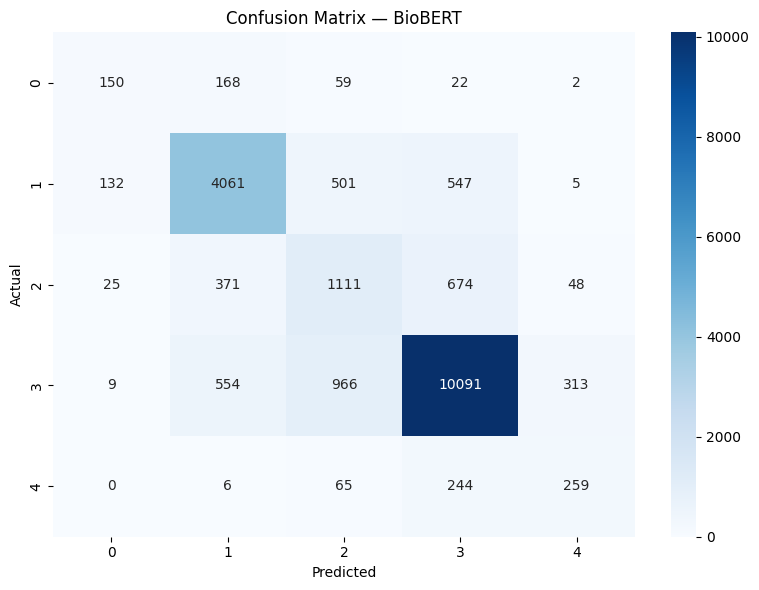

Macro AUC: 0.8836  95% CI [0.8781, 0.8896]
Saved → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/04_leave_one_aspect_out/05_efficacy_cost_only/outputs_text_only/BioBERT_roc_curve.png


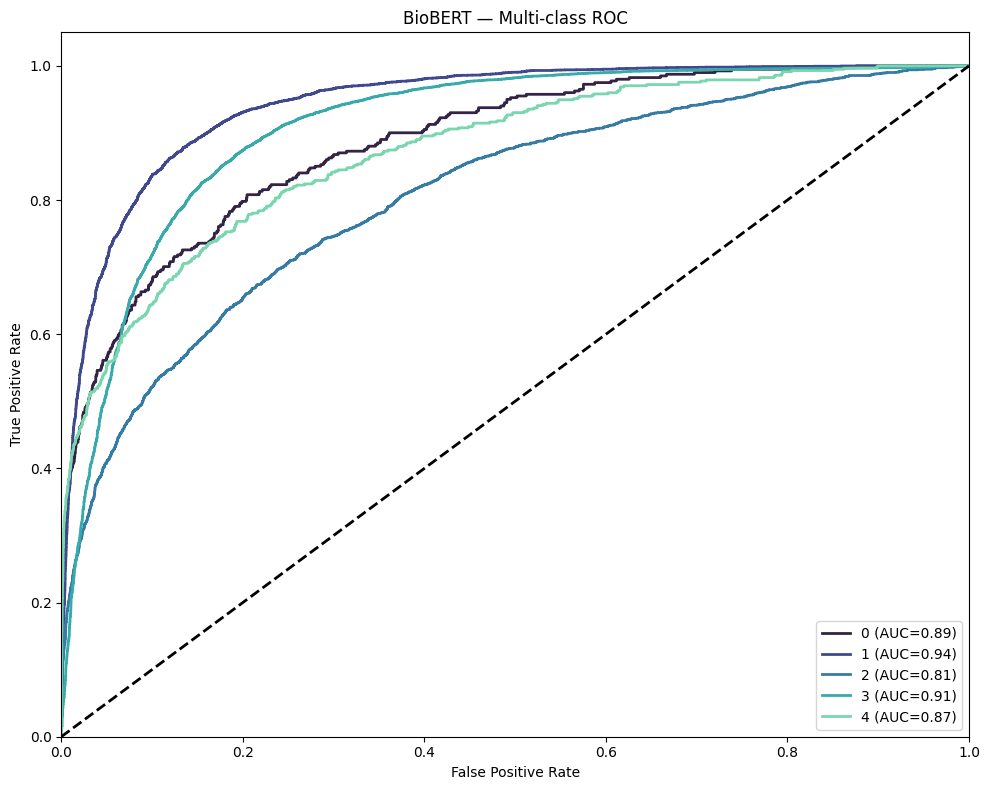

In [ ]:
biobert_preds, biobert_probs, y_true_biobert = evaluate_pytorch(
    best_biobert, test_loader_biobert, label_encoder, "BioBERT", use_attention_mask=True
)

## 4.3 Save Predictions for DL models

In [ ]:
print("\nSaving DL predictions...")

# Verify all DL models evaluated on same test set
assert np.array_equal(y_true_gru, y_true_cnn)
assert np.array_equal(y_true_gru, y_true_albert)
assert np.array_equal(y_true_gru, y_true_biobert)
y_true_dl = y_true_gru

true_names = label_encoder.inverse_transform(y_true_dl)

if "id" in df_test_dl.columns:
    df_pred_dl = df_test_dl[["id", TEXT_COLUMN, LABEL_COLUMN_ENCODED]].copy()
else:
    df_pred_dl = df_test_dl[[TEXT_COLUMN, LABEL_COLUMN_ENCODED]].copy()
    df_pred_dl.insert(0, "id", df_test_dl.index)

df_pred_dl = df_pred_dl.rename(columns={TEXT_COLUMN: "text", LABEL_COLUMN_ENCODED: "true_label_id"})
df_pred_dl["true_label"] = true_names

for name, preds, probs in [
    ("gru", gru_preds, gru_probs),
    ("cnn", cnn_preds, cnn_probs),
    ("albert", albert_preds, albert_probs),
    ("biobert", biobert_preds, biobert_probs),
]:
    df_pred_dl[f"{name}_pred_id"] = preds
    df_pred_dl[f"{name}_pred"] = label_encoder.inverse_transform(preds)
    for i, cls in enumerate(label_encoder.classes_):
        df_pred_dl[f"{name}_prob_{cls}"] = probs[:, i]

dl_pred_path = OUTPUT_PATH / "dl_models_predictions.csv"
df_pred_dl.to_csv(dl_pred_path, index=False)
print(f"Saved DL predictions → {dl_pred_path}")


Saving DL predictions...
Saved DL predictions → /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/04_leave_one_aspect_out/05_efficacy_cost_only/outputs_text_only/dl_models_predictions.csv


# 5. Model Comparison

In [ ]:
print("\n" + "="*60)
print("MODEL COMPARISON — McNemar Pairwise Tests")
print("="*60)

# Load both prediction files
df_ml_pred = pd.read_csv(OUTPUT_PATH / "ml_models_predictions.csv")
df_dl_pred = pd.read_csv(OUTPUT_PATH / "dl_models_predictions.csv")

df_merged = pd.merge(df_ml_pred, df_dl_pred, on=["id", "true_label", "true_label_id"],
                     suffixes=("_ml", "_dl"))
print(f"Merged: {df_merged.shape[0]} rows")

y_true_all = df_merged["true_label_id"].values

# Build prediction dict
model_preds_all = {
    "LR":     label_encoder.transform(df_merged["lr_pred"].values),
    "RF":     label_encoder.transform(df_merged["rf_pred"].values),
    "LGBM":   label_encoder.transform(df_merged["lgbm_pred"].values),
    "GRU":    df_merged["gru_pred_id"].values,
    "CNN":    df_merged["cnn_pred_id"].values,
    "ALBERT": df_merged["albert_pred_id"].values,
    "BioBERT": df_merged["biobert_pred_id"].values,
}

# Verify lengths
for name, arr in model_preds_all.items():
    assert len(arr) == len(y_true_all), f"{name} length mismatch"


def mcnemar_pairwise(y_true, model_preds, method="bonferroni"):
    y_true = np.asarray(y_true)
    names = list(model_preds.keys())
    results = []

    for m1, m2 in combinations(names, 2):
        y1, y2 = np.asarray(model_preds[m1]), np.asarray(model_preds[m2])
        c1 = (y1 == y_true)
        c2 = (y2 == y_true)

        a = np.sum(c1 & c2)
        b = np.sum(c1 & ~c2)
        c = np.sum(~c1 & c2)
        d = np.sum(~c1 & ~c2)

        res = mcnemar(np.array([[a, b], [c, d]]), exact=False, correction=True)
        p = res.pvalue

        if p >= 0.05:
            winner = "Inconclusive"
        elif b > c:
            winner = f"{m1} > {m2}"
        elif c > b:
            winner = f"{m2} > {m1}"
        else:
            winner = "Tie"

        results.append({
            "Model_1": m1, "Model_2": m2,
            "both_correct": a, "m1_only": b, "m2_only": c, "both_wrong": d,
            "statistic": res.statistic, "p_raw": p, "winner_raw": winner,
        })

    raw_p = [r["p_raw"] for r in results]
    _, corrected_p, _, _ = multipletests(raw_p, method=method)

    for i, pc in enumerate(corrected_p):
        results[i]["p_corrected"] = pc
        results[i]["significant"] = "Yes" if pc < 0.05 else "No"

    df_res = pd.DataFrame(results)
    print(f"\nPairwise McNemar Tests (corrected: {method}):")
    print(df_res.to_string(index=False))
    return df_res


df_mcnemar = mcnemar_pairwise(y_true_all, model_preds_all)

# Save
mcnemar_path = OUTPUT_PATH / "mcnemar_results.csv"
df_mcnemar.to_csv(mcnemar_path, index=False)
print(f"\nSaved McNemar results → {mcnemar_path}")

print("\n✓ Pipeline complete.")


MODEL COMPARISON — McNemar Pairwise Tests
Merged: 20383 rows

Pairwise McNemar Tests (corrected: bonferroni):
Model_1 Model_2  both_correct  m1_only  m2_only  both_wrong   statistic         p_raw       winner_raw   p_corrected significant
     LR      RF         12684     2001     1235        4463  180.848269  3.163815e-41          LR > RF  6.644011e-40         Yes
     LR    LGBM         13665     1020      912        4786    5.925983  1.491921e-02        LR > LGBM  3.133034e-01          No
     LR     GRU         11317     3368     1965        3733  368.573786  3.825839e-82         LR > GRU  8.034263e-81         Yes
     LR     CNN         12818     1867     1786        3912    1.751985  1.856274e-01     Inconclusive  1.000000e+00          No
     LR  ALBERT         12660     2025     2889        2809  151.560643  7.904086e-35      ALBERT > LR  1.659858e-33         Yes
     LR BioBERT         12798     1887     2874        2824  204.199958  2.531357e-46     BioBERT > LR  5.315849e-4

# 6. Add Additional Metric: MAE \& QWK

In [10]:
# ============================================================
# Ordinal metrics for this notebook:
# MAE and Quadratic Weighted Kappa (QWK)
# with 95% bootstrap CI, 1000 bootstrap samples
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import cohen_kappa_score

N_BOOT = 1000
BOOT_SEED = 20260510

OUTPUT_PATH = Path(OUTPUT_PATH)

PREDICTION_FILES = [
    OUTPUT_PATH / "ml_models_predictions.csv",
    OUTPUT_PATH / "dl_models_predictions.csv",
]

# Explicit ordinal mapping from your notebook config
LABEL_TO_ID = {label: i for i, label in enumerate(CLASS_NAMES)}
ID_TO_LABEL = {i: label for label, i in LABEL_TO_ID.items()}

def to_ordinal_array(x):
    s = pd.Series(x)

    if pd.api.types.is_numeric_dtype(s):
        return s.astype(float).astype(int).to_numpy()

    z = s.astype(str).str.strip().str.upper()
    mapped = z.map(LABEL_TO_ID)

    if mapped.isna().any():
        bad = sorted(z[mapped.isna()].dropna().unique().tolist())[:20]
        raise ValueError(f"Unmapped label values: {bad}")

    return mapped.astype(int).to_numpy()

def mae_score(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

def qwk_score(y_true, y_pred):
    labels = np.arange(len(CLASS_NAMES))
    return float(cohen_kappa_score(y_true, y_pred, labels=labels, weights="quadratic"))

def bootstrap_ci(y_true, y_pred, metric_fn, n_boot=1000, seed=20260510):
    rng = np.random.default_rng(seed)
    n = len(y_true)

    point = metric_fn(y_true, y_pred)
    boot = np.empty(n_boot, dtype=float)

    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boot[b] = metric_fn(y_true[idx], y_pred[idx])

    lo, hi = np.nanpercentile(boot, [2.5, 97.5])
    return point, float(lo), float(hi)

def get_true_column(df):
    if "true_label_id" in df.columns:
        return "true_label_id"
    if "true_label" in df.columns:
        return "true_label"
    raise ValueError("Could not find true-label column. Expected true_label_id or true_label.")

def get_prediction_columns(df):
    # ML: lr_pred, rf_pred, lgbm_pred
    # DL: gru_pred, cnn_pred, albert_pred, biobert_pred
    return [
        c for c in df.columns
        if c.endswith("_pred") and not c.endswith("_pred_id")
    ]

rows = []

for pred_path in PREDICTION_FILES:
    if not pred_path.exists():
        print(f"Skipping missing file: {pred_path}")
        continue

    print(f"Reading: {pred_path}")
    df_pred = pd.read_csv(pred_path)

    true_col = get_true_column(df_pred)
    y_true = to_ordinal_array(df_pred[true_col])

    pred_cols = get_prediction_columns(df_pred)
    if not pred_cols:
        raise ValueError(f"No prediction columns ending in _pred found in {pred_path}")

    for pred_col in pred_cols:
        y_pred = to_ordinal_array(df_pred[pred_col])
        model = pred_col.replace("_pred", "")

        mae, mae_lo, mae_hi = bootstrap_ci(
            y_true,
            y_pred,
            mae_score,
            n_boot=N_BOOT,
            seed=BOOT_SEED,
        )

        qwk, qwk_lo, qwk_hi = bootstrap_ci(
            y_true,
            y_pred,
            qwk_score,
            n_boot=N_BOOT,
            seed=BOOT_SEED + 17,
        )

        rows.append({
            "prediction_file": pred_path.name,
            "model": model,
            "n": len(df_pred),
            "mae": mae,
            "mae_ci_lower": mae_lo,
            "mae_ci_upper": mae_hi,
            "qwk": qwk,
            "qwk_ci_lower": qwk_lo,
            "qwk_ci_upper": qwk_hi,
        })

ordinal_metrics = pd.DataFrame(rows)

display(ordinal_metrics)

save_path = OUTPUT_PATH / "ordinal_mae_qwk_bootstrap.csv"
ordinal_metrics.to_csv(save_path, index=False)
print(f"Saved: {save_path}")


Reading: /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/04_leave_one_aspect_out/05_efficacy_cost_only/outputs_text_only/ml_models_predictions.csv
Reading: /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/04_leave_one_aspect_out/05_efficacy_cost_only/outputs_text_only/dl_models_predictions.csv


,prediction_file,model,n,mae,mae_ci_lower,mae_ci_upper,qwk,qwk_ci_lower,qwk_ci_upper
0,ml_models_predictions.csv,lr,20383,0.433548,0.423392,0.443616,0.552808,0.540401,0.564965
1,ml_models_predictions.csv,rf,20383,0.517637,0.507130,0.529166,0.485271,0.471863,0.498263
2,ml_models_predictions.csv,lgbm,20383,0.446156,0.435458,0.456460,0.536853,0.524022,0.549434
3,dl_models_predictions.csv,gru,20383,0.500809,0.490260,0.511261,0.573355,0.561565,0.584191
4,dl_models_predictions.csv,cnn,20383,0.411863,0.401992,0.421675,0.612301,0.600945,0.623261
5,dl_models_predictions.csv,albert,20383,0.306873,0.298777,0.315020,0.750862,0.742407,0.758700
6,dl_models_predictions.csv,biobert,20383,0.299220,0.291216,0.306924,0.755764,0.747409,0.764278


Saved: /content/drive/MyDrive/NLP_Projects/03_DrugReview/02_R1/04_leave_one_aspect_out/05_efficacy_cost_only/outputs_text_only/ordinal_mae_qwk_bootstrap.csv
